In [11]:
%matplotlib inline
import glob
import numpy as np
import random
import pandas as pd
import seaborn as sns; sns.set()
import os
from tqdm import tqdm
from scipy import stats
import matplotlib.pyplot as plt

from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker 
from nilearn import plotting,image, glm
from nilearn.glm.second_level import SecondLevelModel
from nilearn.glm import threshold_stats_img
from nilearn.connectome import ConnectivityMeasure

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline 
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import permutation_test_score
from pathlib import Path

from nltools.stats import fdr, norm

from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score


import joblib
import numpy as np
from pathlib import Path

# pour enlever les warnings
import warnings
warnings.filterwarnings('ignore')

import statistics

# Data set prep

In [12]:
# load dataset containing sex and participant id
df = pd.read_csv("/home/xlajoie/Documents/df_cogn_MCI_AD_new.csv")
df

,RID,Sex,Groupe,Education,Ethnicity,Race,Age_Cognition,Diagnosis,PHC_MEM,PHC_MEM_SE,...,Veg_Intru,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL,Race_binary,Race_matrix
0,6,2,1,13,2.0,5,80.495551,2,-0.246,0.170,...,0.0,49,0,0,168,1,0,25,1,White
1,30,2,2,19,2.0,5,80.052019,2,-0.077,0.168,...,0.0,47,0,0,139,0,0,21,1,White
2,33,1,1,20,2.0,5,83.523614,2,-0.332,0.153,...,0.0,34,0,0,-1,-1,-1,27,1,White
3,38,1,1,12,2.0,5,76.952772,2,-0.002,0.172,...,0.0,61,0,0,300,1,10,26,1,White
4,41,2,2,14,2.0,5,71.036277,2,-0.928,0.156,...,0.0,18,0,0,145,2,0,29,1,White
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758,5031,2,2,14,1.0,5,80.605065,2,-0.198,0.178,...,NaN,31,0,0,73,1,0,18,1,White
759,5047,2,1,16,2.0,3,69.004791,2,0.005,0.152,...,NaN,28,0,0,66,0,0,26,2,NonWhite
760,5066,1,1,17,2.0,5,79.942505,2,0.573,0.172,...,NaN,50,0,0,156,1,0,26,1,White
761,5099,2,1,16,2.0,5,61.694730,2,0.480,0.184,...,NaN,59,0,0,98,0,0,29,1,White


In [13]:
df.columns

Index(['RID', 'Sex', 'Groupe', 'Education', 'Ethnicity', 'Race',
       'Age_Cognition', 'Diagnosis', 'PHC_MEM', 'PHC_MEM_SE', 'PHC_EXF',
       'PHC_EXF_SE', 'PHC_LAN', 'PHC_LAN_SE', 'PHC_VSP', 'PHC_VSP_SE',
       'ADAS_Score', 'CDR_Score', 'ECOG_Score', 'FAQ_Score', 'GDS_Score',
       'MMSE_Score', 'MoCA_Score', 'Anxiety_Score', 'Logical_MEM_imm',
       'Logical_MEM_delay', 'CLOCKSCOR', 'COPYSCOR', 'DSPANFOR', 'DSPANFLTH',
       'DSPANBAC', 'DSPANBLTH', 'AVLT_Total', 'AVDEL30MIN', 'AVRECOGTOT',
       'Animals_Total', 'Animals_Pers', 'Animals_Intru', 'Veg_Total',
       'Veg_Pers', 'Veg_Intru', 'Trail_A_Time', 'Trail_A_Comm', 'Trail_A_Omm',
       'Trail_B_Time', 'Trail_B_Comm', 'Trail_B_Omm', 'BNTTOTAL',
       'Race_binary', 'Race_matrix'],
      dtype='object')

In [14]:
print("hommes = ", df["Sex"].value_counts()[1])
print("femmes = ", df["Sex"].value_counts()[2])

hommes =  453
femmes =  310


## Gestion valeurs manquantes

In [15]:
columns = df.columns 


for val in columns:  
    if df[val].isnull().values.any():
        print(val)

Ethnicity
ECOG_Score
MoCA_Score
Anxiety_Score
DSPANFOR
DSPANFLTH
DSPANBAC
DSPANBLTH
Veg_Total
Veg_Pers
Veg_Intru


In [16]:
# Shows only columns with missing values and how many they have
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
print(missing_counts)


Ethnicity          3
ECOG_Score       613
MoCA_Score       241
Anxiety_Score    245
DSPANFOR         388
DSPANFLTH        388
DSPANBAC         388
DSPANBLTH        388
Veg_Total        388
Veg_Pers         388
Veg_Intru        388
dtype: int64


In [17]:
#here we drop all columns that have too many missing values
# + drop these columns inutile : ['PHASE',  'VISCODE', 'VISCODE2','Diagnosis', 'PHC_MEM_SE', 'PHC_EXF_SE', 'PHC_LAN_SE', 'PHC_VSP_SE', 'PHC_Visit', 'GENOTYPE']

new_df = df.drop(columns=['ECOG_Score','MoCA_Score', 'Anxiety_Score', 'DSPANFOR', 
                          'DSPANFLTH','DSPANBAC','DSPANBLTH','Veg_Total', 'Veg_Pers', 'Veg_Intru','Diagnosis', 'PHC_MEM_SE', 'PHC_EXF_SE',
                          'PHC_LAN_SE', 'PHC_VSP_SE','Ethnicity', 'Race_binary', 'Race_matrix'])
                        
new_df


,RID,Sex,Groupe,Education,Race,Age_Cognition,PHC_MEM,PHC_EXF,PHC_LAN,PHC_VSP,...,Animals_Total,Animals_Pers,Animals_Intru,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL
0,6,2,1,13,5,80.495551,-0.246,-0.200,0.065,-0.237,...,13,4,0,49,0,0,168,1,0,25
1,30,2,2,19,5,80.052019,-0.077,0.042,0.180,0.963,...,16,3,0,47,0,0,139,0,0,21
2,33,1,1,20,5,83.523614,-0.332,0.257,0.045,0.963,...,16,0,0,34,0,0,-1,-1,-1,27
3,38,1,1,12,5,76.952772,-0.002,-0.594,0.411,0.264,...,19,1,0,61,0,0,300,1,10,26
4,41,2,2,14,5,71.036277,-0.928,0.719,0.865,0.264,...,18,7,0,18,0,0,145,2,0,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758,5031,2,2,14,5,80.605065,-0.198,-0.305,-0.706,-0.094,...,8,0,0,31,0,0,73,1,0,18
759,5047,2,1,16,3,69.004791,0.005,0.839,0.288,0.963,...,13,1,0,28,0,0,66,0,0,26
760,5066,1,1,17,5,79.942505,0.573,0.497,0.519,0.264,...,21,0,0,50,0,0,156,1,0,26
761,5099,2,1,16,5,61.694730,0.480,0.192,0.944,0.264,...,22,0,0,59,0,0,98,0,0,29


In [18]:
new_df.isnull().sum(axis = 0)

RID                  0
Sex                  0
Groupe               0
Education            0
Race                 0
Age_Cognition        0
PHC_MEM              0
PHC_EXF              0
PHC_LAN              0
PHC_VSP              0
ADAS_Score           0
CDR_Score            0
FAQ_Score            0
GDS_Score            0
MMSE_Score           0
Logical_MEM_imm      0
Logical_MEM_delay    0
CLOCKSCOR            0
COPYSCOR             0
AVLT_Total           0
AVDEL30MIN           0
AVRECOGTOT           0
Animals_Total        0
Animals_Pers         0
Animals_Intru        0
Trail_A_Time         0
Trail_A_Comm         0
Trail_A_Omm          0
Trail_B_Time         0
Trail_B_Comm         0
Trail_B_Omm          0
BNTTOTAL             0
dtype: int64

In [19]:
print("MCI-MCI = ", new_df["Groupe"].value_counts()[1])
print("MCI-AD = ", new_df["Groupe"].value_counts()[2])

MCI-MCI =  435
MCI-AD =  328


In [20]:
sex_counts_by_group = new_df.groupby("Groupe")["Sex"].value_counts().unstack()
print(sex_counts_by_group)


Sex       1    2
Groupe          
1       254  181
2       199  129


In [21]:
print(new_df["Race"].value_counts())


Race
5    716
3     26
2     13
6      4
1      2
4      2
Name: count, dtype: int64


In [22]:
#here replace race by 1= white 2 = non white 

In [23]:
new_df["Race"] = new_df["Race"].apply(lambda x: 0 if x == 5 else 1)


In [24]:
new_df

,RID,Sex,Groupe,Education,Race,Age_Cognition,PHC_MEM,PHC_EXF,PHC_LAN,PHC_VSP,...,Animals_Total,Animals_Pers,Animals_Intru,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL
0,6,2,1,13,0,80.495551,-0.246,-0.200,0.065,-0.237,...,13,4,0,49,0,0,168,1,0,25
1,30,2,2,19,0,80.052019,-0.077,0.042,0.180,0.963,...,16,3,0,47,0,0,139,0,0,21
2,33,1,1,20,0,83.523614,-0.332,0.257,0.045,0.963,...,16,0,0,34,0,0,-1,-1,-1,27
3,38,1,1,12,0,76.952772,-0.002,-0.594,0.411,0.264,...,19,1,0,61,0,0,300,1,10,26
4,41,2,2,14,0,71.036277,-0.928,0.719,0.865,0.264,...,18,7,0,18,0,0,145,2,0,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758,5031,2,2,14,0,80.605065,-0.198,-0.305,-0.706,-0.094,...,8,0,0,31,0,0,73,1,0,18
759,5047,2,1,16,1,69.004791,0.005,0.839,0.288,0.963,...,13,1,0,28,0,0,66,0,0,26
760,5066,1,1,17,0,79.942505,0.573,0.497,0.519,0.264,...,21,0,0,50,0,0,156,1,0,26
761,5099,2,1,16,0,61.694730,0.480,0.192,0.944,0.264,...,22,0,0,59,0,0,98,0,0,29


In [25]:
new_df["Sex"] = new_df["Sex"].apply(lambda x: 0 if x == 1 else 1)
new_df

,RID,Sex,Groupe,Education,Race,Age_Cognition,PHC_MEM,PHC_EXF,PHC_LAN,PHC_VSP,...,Animals_Total,Animals_Pers,Animals_Intru,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL
0,6,1,1,13,0,80.495551,-0.246,-0.200,0.065,-0.237,...,13,4,0,49,0,0,168,1,0,25
1,30,1,2,19,0,80.052019,-0.077,0.042,0.180,0.963,...,16,3,0,47,0,0,139,0,0,21
2,33,0,1,20,0,83.523614,-0.332,0.257,0.045,0.963,...,16,0,0,34,0,0,-1,-1,-1,27
3,38,0,1,12,0,76.952772,-0.002,-0.594,0.411,0.264,...,19,1,0,61,0,0,300,1,10,26
4,41,1,2,14,0,71.036277,-0.928,0.719,0.865,0.264,...,18,7,0,18,0,0,145,2,0,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758,5031,1,2,14,0,80.605065,-0.198,-0.305,-0.706,-0.094,...,8,0,0,31,0,0,73,1,0,18
759,5047,1,1,16,1,69.004791,0.005,0.839,0.288,0.963,...,13,1,0,28,0,0,66,0,0,26
760,5066,0,1,17,0,79.942505,0.573,0.497,0.519,0.264,...,21,0,0,50,0,0,156,1,0,26
761,5099,1,1,16,0,61.694730,0.480,0.192,0.944,0.264,...,22,0,0,59,0,0,98,0,0,29


In [26]:
new_df["Groupe"] = new_df["Groupe"].apply(lambda x: 0 if x == 1 else 1)
new_df

,RID,Sex,Groupe,Education,Race,Age_Cognition,PHC_MEM,PHC_EXF,PHC_LAN,PHC_VSP,...,Animals_Total,Animals_Pers,Animals_Intru,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL
0,6,1,0,13,0,80.495551,-0.246,-0.200,0.065,-0.237,...,13,4,0,49,0,0,168,1,0,25
1,30,1,1,19,0,80.052019,-0.077,0.042,0.180,0.963,...,16,3,0,47,0,0,139,0,0,21
2,33,0,0,20,0,83.523614,-0.332,0.257,0.045,0.963,...,16,0,0,34,0,0,-1,-1,-1,27
3,38,0,0,12,0,76.952772,-0.002,-0.594,0.411,0.264,...,19,1,0,61,0,0,300,1,10,26
4,41,1,1,14,0,71.036277,-0.928,0.719,0.865,0.264,...,18,7,0,18,0,0,145,2,0,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758,5031,1,1,14,0,80.605065,-0.198,-0.305,-0.706,-0.094,...,8,0,0,31,0,0,73,1,0,18
759,5047,1,0,16,1,69.004791,0.005,0.839,0.288,0.963,...,13,1,0,28,0,0,66,0,0,26
760,5066,0,0,17,0,79.942505,0.573,0.497,0.519,0.264,...,21,0,0,50,0,0,156,1,0,26
761,5099,1,0,16,0,61.694730,0.480,0.192,0.944,0.264,...,22,0,0,59,0,0,98,0,0,29


In [27]:
new_df.to_csv("/data/brambati/Xanthy/ADNI/new_df.csv", index=False)

In [28]:
# t-test to see if mci stable and mci converter groups differ in age and education levels 

In [29]:
from scipy.stats import ttest_ind

# Separate the groups
group_stable = new_df[new_df["Groupe"] == 0]
group_converters = new_df[new_df["Groupe"] == 1]

# T-test for Age
t_age, p_age = ttest_ind(group_stable["Age_Cognition"], group_converters["Age_Cognition"], equal_var=False)

# T-test for Education
t_edu, p_edu = ttest_ind(group_stable["Education"], group_converters["Education"], equal_var=False)

print(f"T-test for Age: t = {t_age:.3f}, p = {p_age:.4f}")
print(f"T-test for Education: t = {t_edu:.3f}, p = {p_edu:.4f}")


T-test for Age: t = -1.635, p = 0.1026
T-test for Education: t = -0.235, p = 0.8146


In [30]:
# Group by 'Groupe' and calculate mean and std for Age and Education
demographic_stats = new_df.groupby("Groupe")[["Age_Cognition", "Education"]].agg(["mean", "std", "count"])

# Rename index if you want clearer labels
demographic_stats.index = ["MCI-stable", "MCI-converter"]

print(demographic_stats)


              Age_Cognition                  Education                
                       mean       std count       mean       std count
MCI-stable        73.314351  7.710281   435  15.841379  2.929296   435
MCI-converter     74.193528  7.075522   328  15.890244  2.787065   328


In [31]:
# chi square to see if sex ratio is different 

In [32]:
import pandas as pd
from scipy.stats import chi2_contingency

# Create a contingency table of Sex by Group
contingency_table = pd.crosstab(new_df["Groupe"], new_df["Sex"])

# Perform chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Contingency Table:")
print(contingency_table)
print(f"\nChi-square Statistic = {chi2:.3f}")
print(f"p-value = {p:.4f}")


Contingency Table:
Sex       0    1
Groupe          
0       254  181
1       199  129

Chi-square Statistic = 0.314
p-value = 0.5752


# Classification MCI-MCI vs MCI_AD

In [33]:
new_df = pd.read_csv("/data/brambati/Xanthy/ADNI/new_df.csv")  #df1 = sans donnees manquantes seulement & retrait de colonnes avec plusieurs donnees manquantes
new_df

,RID,Sex,Groupe,Education,Race,Age_Cognition,PHC_MEM,PHC_EXF,PHC_LAN,PHC_VSP,...,Animals_Total,Animals_Pers,Animals_Intru,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL
0,6,1,0,13,0,80.495551,-0.246,-0.200,0.065,-0.237,...,13,4,0,49,0,0,168,1,0,25
1,30,1,1,19,0,80.052019,-0.077,0.042,0.180,0.963,...,16,3,0,47,0,0,139,0,0,21
2,33,0,0,20,0,83.523614,-0.332,0.257,0.045,0.963,...,16,0,0,34,0,0,-1,-1,-1,27
3,38,0,0,12,0,76.952772,-0.002,-0.594,0.411,0.264,...,19,1,0,61,0,0,300,1,10,26
4,41,1,1,14,0,71.036277,-0.928,0.719,0.865,0.264,...,18,7,0,18,0,0,145,2,0,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758,5031,1,1,14,0,80.605065,-0.198,-0.305,-0.706,-0.094,...,8,0,0,31,0,0,73,1,0,18
759,5047,1,0,16,1,69.004791,0.005,0.839,0.288,0.963,...,13,1,0,28,0,0,66,0,0,26
760,5066,0,0,17,0,79.942505,0.573,0.497,0.519,0.264,...,21,0,0,50,0,0,156,1,0,26
761,5099,1,0,16,0,61.694730,0.480,0.192,0.944,0.264,...,22,0,0,59,0,0,98,0,0,29


# 1. classify cognitive profiles without composite scores 

In [34]:
df1 = new_df.drop(columns=['PHC_MEM', 'PHC_EXF', 'PHC_LAN', 'PHC_VSP'])
df1

,RID,Sex,Groupe,Education,Race,Age_Cognition,ADAS_Score,CDR_Score,FAQ_Score,GDS_Score,...,Animals_Total,Animals_Pers,Animals_Intru,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL
0,6,1,0,13,0,80.495551,18.67,0.5,0,0,...,13,4,0,49,0,0,168,1,0,25
1,30,1,1,19,0,80.052019,10.00,0.5,6,1,...,16,3,0,47,0,0,139,0,0,21
2,33,0,0,20,0,83.523614,17.67,0.5,6,2,...,16,0,0,34,0,0,-1,-1,-1,27
3,38,0,0,12,0,76.952772,11.33,0.5,1,4,...,19,1,0,61,0,0,300,1,10,26
4,41,1,1,14,0,71.036277,18.33,0.5,4,2,...,18,7,0,18,0,0,145,2,0,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758,5031,1,1,14,0,80.605065,9.00,0.5,9,1,...,8,0,0,31,0,0,73,1,0,18
759,5047,1,0,16,1,69.004791,10.00,0.5,0,1,...,13,1,0,28,0,0,66,0,0,26
760,5066,0,0,17,0,79.942505,11.00,0.5,0,1,...,21,0,0,50,0,0,156,1,0,26
761,5099,1,0,16,0,61.694730,9.00,0.5,4,2,...,22,0,0,59,0,0,98,0,0,29


In [35]:
x = df1.drop(['Groupe','RID'], axis =1)
y = df1["Groupe"].to_numpy()

In [36]:
def machine_learning(x, y):
    # Split the sample into training/test with an 80/20 ratio
    X_train, X_test, y_train, y_test = train_test_split(
        x, y,
        test_size=0.2,
        shuffle=True,
        stratify=y,
        random_state=123
    )

    # Build pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LinearSVC(max_iter=10000))
    ])

    # Cross-validation on training set
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=10, n_jobs=3)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()

    # Fit pipeline and predict on test set
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Accuracy
    acc_test = pipeline.score(X_test, y_test)
    acc_train = pipeline.score(X_train, y_train)

    # Confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = conf_matrix.ravel()
    df_result = pd.DataFrame(
        data=[[tn, fp], [fn, tp]],
        index=["MCI_stable", "MCI_convert"],
        columns=["MCI_stable", "MCI_convert"]
    ).rename_axis("Actual class").rename_axis("Predicted class", axis="columns")

    # AUC using decision function
    y_scores = pipeline.decision_function(X_test)
    auc = roc_auc_score(y_test, y_scores)

    # Full test set DataFrame with misclassification info
    X_test_df = X_test.reset_index(drop=True) if isinstance(X_test, pd.DataFrame) else pd.DataFrame(X_test, columns=x.columns)
    y_test_series = y_test.reset_index(drop=True) if hasattr(y_test, 'reset_index') else pd.Series(y_test)
    y_pred_series = pd.Series(y_pred)

    X_test_df["True_Label"] = y_test_series.values
    X_test_df["Predicted_Label"] = y_pred_series.values
    X_test_df["Misclassified"] = X_test_df["True_Label"] != X_test_df["Predicted_Label"]

    # Feature importance
    feature_names = X_train.columns if isinstance(X_train, pd.DataFrame) else [f"feature_{i}" for i in range(X_train.shape[1])]
    clf = pipeline.named_steps["clf"]
    coefficients = clf.coef_.flatten()
    feature_importance = pd.Series(coefficients, index=feature_names).sort_values(key=abs, ascending=False)

    print(feature_importance)

    return {
        "len_X_train": len(X_train),
        "len_X_test": len(X_test),
        "cv_scores": cv_scores,
        "cv_mean": cv_mean,          # Average CV accuracy
        "cv_std": cv_std,
        "confusion_matrix": df_result,
        "acc_test": acc_test,
        "acc_train": acc_train,
        "auc": auc,
        "pipeline": pipeline,
        "X_test_df": X_test_df,      # ✅ Full test set with all points
        "feature_importance": feature_importance,
    }


In [37]:
run = machine_learning(x,y)
run

Logical_MEM_delay   -0.281078
ADAS_Score           0.194714
FAQ_Score            0.175657
Trail_B_Time         0.169561
Trail_B_Comm        -0.147853
Education            0.136871
Race                -0.086149
AVDEL30MIN          -0.085662
Age_Cognition       -0.059420
BNTTOTAL             0.053245
AVRECOGTOT           0.050910
CDR_Score           -0.049673
AVLT_Total          -0.046760
COPYSCOR             0.042397
CLOCKSCOR           -0.031550
Trail_B_Omm         -0.031192
Trail_A_Comm         0.029046
Animals_Pers         0.025654
Animals_Intru       -0.025485
Sex                  0.024535
Logical_MEM_imm      0.015943
Trail_A_Time        -0.012049
Animals_Total       -0.009776
GDS_Score           -0.007475
Trail_A_Omm         -0.007246
MMSE_Score          -0.004599
dtype: float64


{'len_X_train': 610,
 'len_X_test': 153,
 'cv_scores': array([0.70491803, 0.70491803, 0.7704918 , 0.7704918 , 0.75409836,
        0.67213115, 0.63934426, 0.72131148, 0.67213115, 0.72131148]),
 'cv_mean': 0.7131147540983606,
 'cv_std': 0.04163418065311571,
 'confusion_matrix': Predicted class  MCI_stable  MCI_convert
 Actual class                            
 MCI_stable               70           17
 MCI_convert              26           40,
 'acc_test': 0.7189542483660131,
 'acc_train': 0.7540983606557377,
 'auc': 0.7697666318355972,
 'pipeline': Pipeline(steps=[('scaler', StandardScaler()),
                 ('clf', LinearSVC(max_iter=10000))]),
 'X_test_df':      Sex  Education  Race  Age_Cognition  ADAS_Score  CDR_Score  FAQ_Score  \
 0      0         19     0      74.729637       17.00        0.5          8   
 1      0         12     0      83.348392       12.00        0.5          7   
 2      0         12     0      56.761123       14.00        0.5          8   
 3      0        

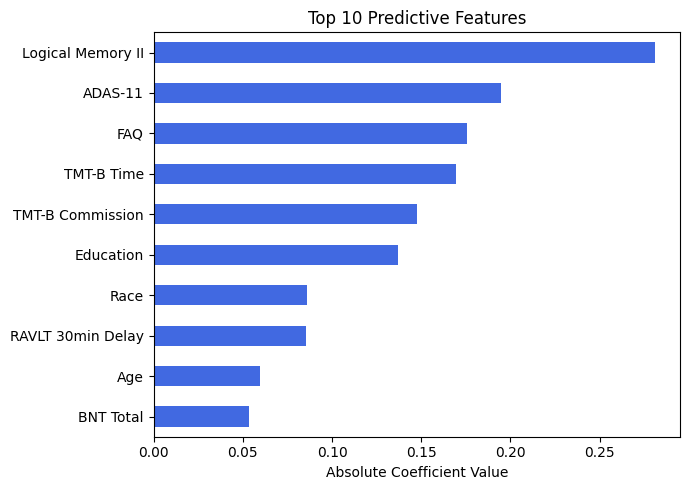

In [137]:
import matplotlib.pyplot as plt

# Set consistent font sizes
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

plt.style.use("default")

# Get feature importance and take absolute value
fi = run["feature_importance"].abs()

# Select top 10 features (largest absolute coefficients)
top10 = fi.sort_values(ascending=False).head(10)

rename_dict = {
    "Logical_MEM_delay": "Logical Memory II",
    "ADAS_Score": "ADAS-11",
    "FAQ_Score": "FAQ",
    "Trail_B_Time": "TMT-B Time",
    "Trail_B_Comm": "TMT-B Commission",
    "AVDEL30MIN": "RAVLT 30min Delay",
    "Age_Cognition": "Age",
    "BNTTOTAL": "BNT Total"
}

top10 = top10.rename(index=rename_dict)

# Sort ascending for horizontal bar plot (largest bar on top)
top10_sorted = top10.sort_values(ascending=True)

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(7, 5))
top10_sorted.plot(kind="barh", ax=ax, width=0.5, color="royalblue")

ax.set_title("Top 10 Predictive Features")
ax.set_xlabel("Absolute Coefficient Value")


plt.subplots_adjust(left=0.35)
plt.tight_layout()

# Save PNG
plt.savefig(
    "top10_features_MCI_AD.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

# Save PDF
plt.savefig(
    "top10_features_MCI_AD.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [39]:
misclassified_df = run["X_test_df"]
misclassified_df

,Sex,Education,Race,Age_Cognition,ADAS_Score,CDR_Score,FAQ_Score,GDS_Score,MMSE_Score,Logical_MEM_imm,...,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL,True_Label,Predicted_Label,Misclassified
0,0,19,0,74.729637,17.00,0.5,8,2,26,3,...,39,0,0,102,2,0,14,1,1,False
1,0,12,0,83.348392,12.00,0.5,7,1,25,8,...,63,0,0,138,0,0,30,0,0,False
2,0,12,0,56.761123,14.00,0.5,8,0,27,6,...,50,0,0,104,1,0,23,1,1,False
3,0,16,0,76.052019,15.00,0.5,5,0,26,13,...,53,0,0,158,0,0,28,1,1,False
4,0,16,0,78.332649,12.00,0.5,0,2,28,5,...,50,0,0,108,2,0,28,0,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,1,16,1,74.729637,14.67,0.5,17,4,24,11,...,51,0,0,110,0,0,24,1,1,False
149,1,16,0,84.657084,10.67,0.5,4,5,26,11,...,62,0,0,167,0,0,26,1,1,False
150,0,12,0,69.831622,12.00,0.5,5,0,26,12,...,89,0,0,230,3,0,26,1,0,True
151,0,18,1,88.095825,11.67,0.5,2,3,24,3,...,42,0,0,191,1,0,24,0,0,False


In [40]:
# save df

misclassified_df.to_csv("/home/xlajoie/Desktop/PhD/misclassified_subjects_MCI_AD.csv", index = False)

In [41]:
# seeing the distribution of those missclassified vs not missclassified 

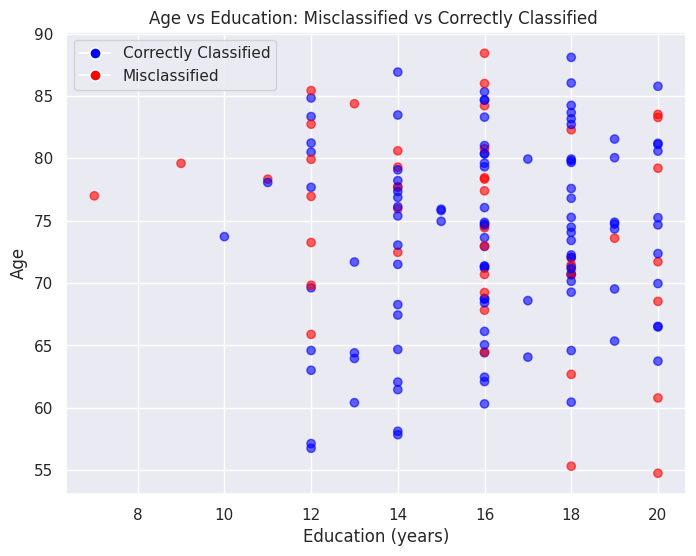

In [42]:
import matplotlib.pyplot as plt

# Get misclassified samples DataFrame
df_plot = run["X_test_df"].copy()

# Add a column for "Misclassified" (True/False)
df_plot["Misclassified"] = df_plot["True_Label"] != df_plot["Predicted_Label"]

# Scatter plot
plt.figure(figsize=(8,6))
colors = {True: 'red', False: 'blue'}

plt.scatter(
    df_plot["Education"], 
    df_plot["Age_Cognition"], 
    c=df_plot["Misclassified"].map(colors),
    alpha=0.6
)

plt.xlabel("Education (years)")
plt.ylabel("Age")
plt.title("Age vs Education: Misclassified vs Correctly Classified ")

# Legend
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label='Correctly Classified',
               markerfacecolor='blue', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Misclassified',
               markerfacecolor='red', markersize=8)
])
plt.show()



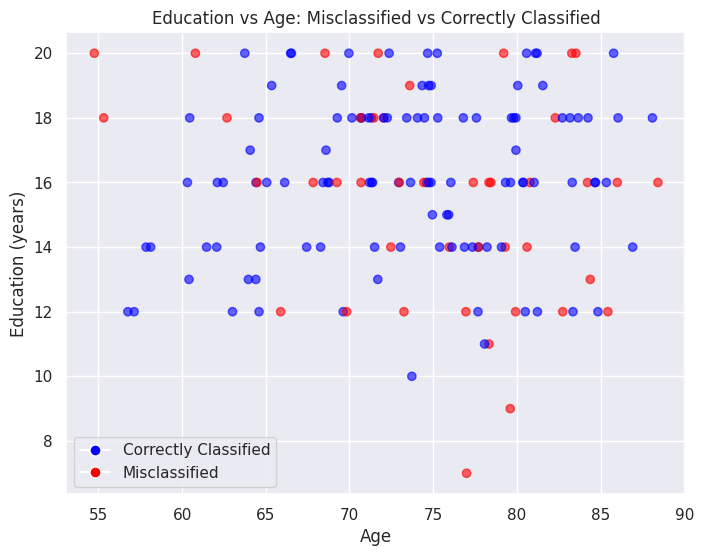

In [43]:
import matplotlib.pyplot as plt

# Use the full test set from the function output
df_plot = run["X_test_df"]

# Scatter plot with swapped axes
plt.figure(figsize=(8,6))
colors = {True: 'red', False: 'blue'}

plt.scatter(
    df_plot['Age_Cognition'],      # x-axis: Age
    df_plot['Education'],          # y-axis: Education
    c=df_plot['Misclassified'].map(colors),
    alpha=0.6
)

plt.xlabel("Age")
plt.ylabel("Education (years)")
plt.title("Education vs Age: Misclassified vs Correctly Classified")

plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label='Correctly Classified', 
               markerfacecolor='blue', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Misclassified', 
               markerfacecolor='red', markersize=8)
])
plt.show()



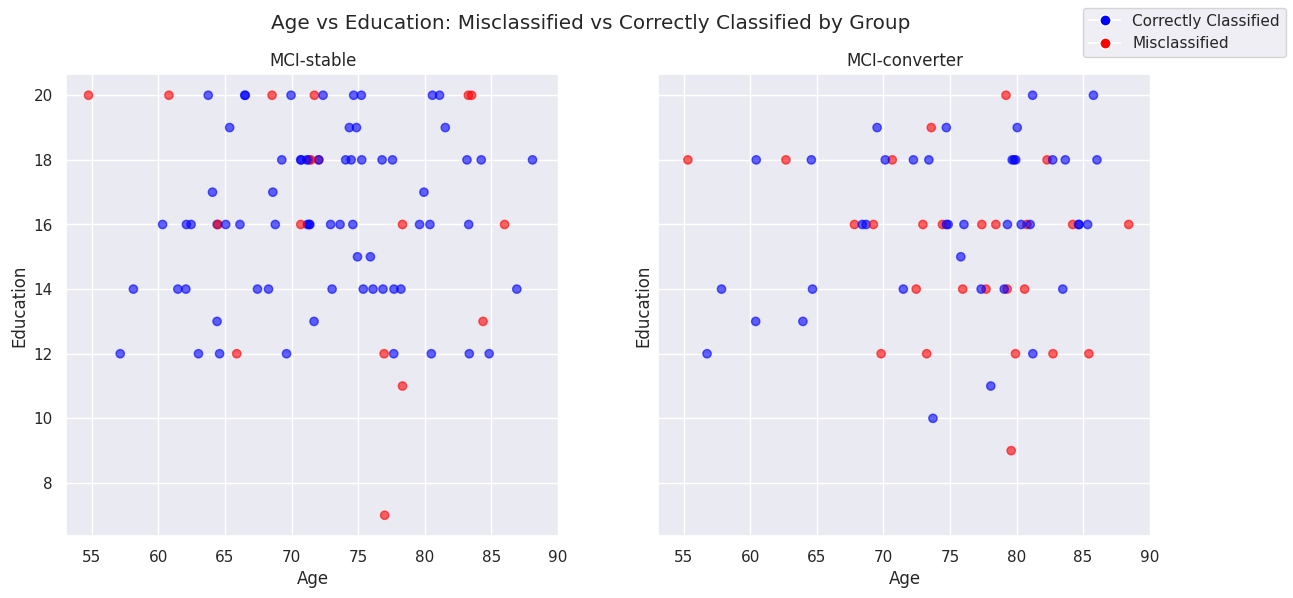

In [44]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Use the full test set from the function output
X_test_df = run["X_test_df"]

# Separate the two groups
group0 = X_test_df[X_test_df['True_Label'] == 0]  # MCI-stable
group1 = X_test_df[X_test_df['True_Label'] == 1]  # MCI-converter

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharex=True, sharey=True)

colors = {True: 'red', False: 'blue'}

# MCI-stable
axes[0].scatter(group0['Age_Cognition'], group0['Education'], 
                c=group0['Misclassified'].map(colors), alpha=0.6)
axes[0].set_title("MCI-stable")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Education")

# MCI-converter
axes[1].scatter(group1['Age_Cognition'], group1['Education'], 
                c=group1['Misclassified'].map(colors), alpha=0.6)
axes[1].set_title("MCI-converter")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Education")

# Shared legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Correctly Classified', 
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Misclassified', 
           markerfacecolor='red', markersize=8)
]
fig.legend(handles=legend_elements, loc='upper right')

plt.suptitle("Age vs Education: Misclassified vs Correctly Classified by Group")
plt.show()


In [45]:
#permutation test on the ml model's accuracy to determine whether the classifier's performance is significantly better than chance

In [46]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.utils import shuffle

# Assume you already have your real accuracy
results = machine_learning(x, y)
real_accuracy = results["acc_test"]
print(f"Observed accuracy: {real_accuracy:.4f}")

# Permutation test
n_permutations = 1000
perm_accuracies = []

for _ in range(n_permutations):
    y_permuted = shuffle(y, random_state=None)
    
    # Split with same method as in your function
    X_train, X_test, y_train, y_test = train_test_split(
        x, y_permuted, test_size=0.2, stratify=y_permuted, shuffle=True, random_state=123
    )
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LinearSVC(max_iter=10000))
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    perm_accuracies.append(acc)

# Compute permutation p-value
perm_accuracies = np.array(perm_accuracies)
p_value = np.mean(perm_accuracies >= real_accuracy)

print(f"Permutation p-value: {p_value:.4f}")


Logical_MEM_delay   -0.281078
ADAS_Score           0.194714
FAQ_Score            0.175657
Trail_B_Time         0.169561
Trail_B_Comm        -0.147852
Education            0.136871
Race                -0.086148
AVDEL30MIN          -0.085663
Age_Cognition       -0.059420
BNTTOTAL             0.053244
AVRECOGTOT           0.050910
CDR_Score           -0.049676
AVLT_Total          -0.046760
COPYSCOR             0.042396
CLOCKSCOR           -0.031550
Trail_B_Omm         -0.031190
Trail_A_Comm         0.029047
Animals_Pers         0.025654
Animals_Intru       -0.025485
Sex                  0.024535
Logical_MEM_imm      0.015943
Trail_A_Time        -0.012048
Animals_Total       -0.009776
GDS_Score           -0.007475
Trail_A_Omm         -0.007246
MMSE_Score          -0.004599
dtype: float64
Observed accuracy: 0.7190


KeyboardInterrupt: 

# 2. Classification seulement scores composite + race, education, age

In [47]:
new_df

,RID,Sex,Groupe,Education,Race,Age_Cognition,PHC_MEM,PHC_EXF,PHC_LAN,PHC_VSP,...,Animals_Total,Animals_Pers,Animals_Intru,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL
0,6,1,0,13,0,80.495551,-0.246,-0.200,0.065,-0.237,...,13,4,0,49,0,0,168,1,0,25
1,30,1,1,19,0,80.052019,-0.077,0.042,0.180,0.963,...,16,3,0,47,0,0,139,0,0,21
2,33,0,0,20,0,83.523614,-0.332,0.257,0.045,0.963,...,16,0,0,34,0,0,-1,-1,-1,27
3,38,0,0,12,0,76.952772,-0.002,-0.594,0.411,0.264,...,19,1,0,61,0,0,300,1,10,26
4,41,1,1,14,0,71.036277,-0.928,0.719,0.865,0.264,...,18,7,0,18,0,0,145,2,0,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758,5031,1,1,14,0,80.605065,-0.198,-0.305,-0.706,-0.094,...,8,0,0,31,0,0,73,1,0,18
759,5047,1,0,16,1,69.004791,0.005,0.839,0.288,0.963,...,13,1,0,28,0,0,66,0,0,26
760,5066,0,0,17,0,79.942505,0.573,0.497,0.519,0.264,...,21,0,0,50,0,0,156,1,0,26
761,5099,1,0,16,0,61.694730,0.480,0.192,0.944,0.264,...,22,0,0,59,0,0,98,0,0,29


In [48]:
new_df.columns

Index(['RID', 'Sex', 'Groupe', 'Education', 'Race', 'Age_Cognition', 'PHC_MEM',
       'PHC_EXF', 'PHC_LAN', 'PHC_VSP', 'ADAS_Score', 'CDR_Score', 'FAQ_Score',
       'GDS_Score', 'MMSE_Score', 'Logical_MEM_imm', 'Logical_MEM_delay',
       'CLOCKSCOR', 'COPYSCOR', 'AVLT_Total', 'AVDEL30MIN', 'AVRECOGTOT',
       'Animals_Total', 'Animals_Pers', 'Animals_Intru', 'Trail_A_Time',
       'Trail_A_Comm', 'Trail_A_Omm', 'Trail_B_Time', 'Trail_B_Comm',
       'Trail_B_Omm', 'BNTTOTAL'],
      dtype='object')

In [49]:
df2 = new_df.drop(columns=['ADAS_Score', 'CDR_Score', 'FAQ_Score',
       'GDS_Score', 'MMSE_Score', 'Logical_MEM_imm', 'Logical_MEM_delay',
       'CLOCKSCOR', 'COPYSCOR', 'AVLT_Total', 'AVDEL30MIN', 'AVRECOGTOT',
       'Animals_Total', 'Animals_Pers', 'Animals_Intru', 'Trail_A_Time',
       'Trail_A_Comm', 'Trail_A_Omm', 'Trail_B_Time', 'Trail_B_Comm',
       'Trail_B_Omm', 'BNTTOTAL'])
df2

,RID,Sex,Groupe,Education,Race,Age_Cognition,PHC_MEM,PHC_EXF,PHC_LAN,PHC_VSP
0,6,1,0,13,0,80.495551,-0.246,-0.200,0.065,-0.237
1,30,1,1,19,0,80.052019,-0.077,0.042,0.180,0.963
2,33,0,0,20,0,83.523614,-0.332,0.257,0.045,0.963
3,38,0,0,12,0,76.952772,-0.002,-0.594,0.411,0.264
4,41,1,1,14,0,71.036277,-0.928,0.719,0.865,0.264
...,...,...,...,...,...,...,...,...,...,...
758,5031,1,1,14,0,80.605065,-0.198,-0.305,-0.706,-0.094
759,5047,1,0,16,1,69.004791,0.005,0.839,0.288,0.963
760,5066,0,0,17,0,79.942505,0.573,0.497,0.519,0.264
761,5099,1,0,16,0,61.694730,0.480,0.192,0.944,0.264


In [50]:
x2 = df2.drop(['Groupe','RID'], axis =1)
y2 = df2["Groupe"].to_numpy()

In [51]:
run2 = machine_learning(x2,y2)
run2

PHC_MEM         -0.479974
Education        0.112395
Race            -0.089585
PHC_VSP          0.083306
PHC_EXF         -0.075236
Age_Cognition   -0.067795
Sex              0.038611
PHC_LAN          0.002888
dtype: float64


{'len_X_train': 610,
 'len_X_test': 153,
 'cv_scores': array([0.70491803, 0.6557377 , 0.60655738, 0.73770492, 0.67213115,
        0.68852459, 0.6557377 , 0.70491803, 0.60655738, 0.75409836]),
 'cv_mean': 0.6786885245901638,
 'cv_std': 0.047058033096417456,
 'confusion_matrix': Predicted class  MCI_stable  MCI_convert
 Actual class                            
 MCI_stable               71           16
 MCI_convert              29           37,
 'acc_test': 0.7058823529411765,
 'acc_train': 0.6934426229508197,
 'auc': 0.7403343782654127,
 'pipeline': Pipeline(steps=[('scaler', StandardScaler()),
                 ('clf', LinearSVC(max_iter=10000))]),
 'X_test_df':      Sex  Education  Race  Age_Cognition  PHC_MEM  PHC_EXF  PHC_LAN  PHC_VSP  \
 0      0         19     0      74.729637   -0.250   -0.471   -0.095    0.963   
 1      0         12     0      83.348392   -0.182    0.268   -0.040   -0.422   
 2      0         12     0      56.761123   -0.453    0.508   -0.224    0.264   
 3      

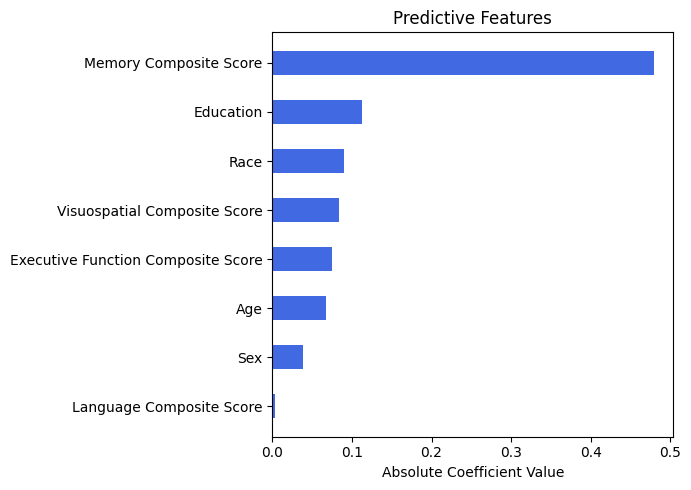

In [133]:
import matplotlib.pyplot as plt

# Set consistent font sizes (same as your other figure)
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

plt.style.use("default")

# Get feature importance and take absolute value
fi = run2["feature_importance"].abs()

# Rename labels
rename_dict = {
    "PHC_MEM": "Memory Composite Score",
    "PHC_VSP": "Visuospatial Composite Score",
    "PHC_EXF": "Executive Function Composite Score",
    "Age_Cognition": "Age",
    "PHC_LAN": "Language Composite Score",
}

fi = fi.rename(index=rename_dict)

# Sort so largest appears at top
fi_sorted = fi.sort_values(ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(fi_sorted.index, fi_sorted.values,height=0.5, color="royalblue")

ax.set_title("Predictive Features")
ax.set_xlabel("Absolute Coefficient Value")

plt.tight_layout()

# Save PNG
plt.savefig(
    "/home/xlajoie/Desktop/PhD/ADNI/composite_features.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

# Save PDF (vector - best for journal)
plt.savefig(
    "/home/xlajoie/Desktop/PhD/ADNI/composite_features.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [53]:
misclassified_df_2 = run2["X_test_df"]
misclassified_df_2

misclassified_df_2.to_csv("/home/xlajoie/Desktop/PhD/misclassified_subjects_MCI_AD_2.csv", index = False)

# Classification hommes 

## prep df

In [ ]:
df = pd.read_csv("/home/xlajoie/Documents/df_cogn_MCI_AD_new.csv")
df

In [ ]:
# 1) drop women subjects 

In [ ]:
df_men = df[df["Sex"] == 1].copy()

In [ ]:
df_men.columns

In [ ]:
df_men = df_men.drop(columns=["Sex", 'Diagnosis','Ethnicity', 'PHC_MEM_SE', 'PHC_EXF_SE',
                          'PHC_LAN_SE', 'PHC_VSP_SE','MoCA_Score', 'Veg_Total', 'Veg_Pers', 'Veg_Intru', 'ECOG_Score', 'Anxiety_Score', 'DSPANFOR', 
                          'DSPANFLTH','DSPANBAC','DSPANBLTH', 'Veg_Total', 'Veg_Pers','Veg_Intru', 'Race_binary', 'Race_matrix'])

In [ ]:
df_men.isnull().sum(axis = 0)

In [ ]:
print(df_men["Race"].value_counts())

In [ ]:
df_men["Race"] = df_men["Race"].apply(lambda x: 0 if x == 5 else 1)
df_men

In [ ]:
df_men["Groupe"] = df_men["Groupe"].apply(lambda x: 0 if x == 1 else 1)
df_men

In [ ]:
# import pandas as pd
# from sklearn.preprocessing import OneHotEncoder

# # Use pd.get_dummies() to one-hot encode the categorical columns
# df_pandas_encoded_men = pd.get_dummies(df_men, columns=['Race'], drop_first=True)
# print(f"One-Hot Encoded Data using Pandas:\n{df_pandas_encoded_men.head()}\n")  # fix variable name here

# categorical_columns = ['Race']
# encoder_men = OneHotEncoder(sparse_output=False)

# one_hot_encoded_men = encoder_men.fit_transform(df_men[categorical_columns])

# one_hot_df_men = pd.DataFrame(one_hot_encoded_men, 
#                               columns=encoder_men.get_feature_names_out(categorical_columns))

# # Reset index on both before concatenation to avoid NaNs
# df_men_reset = df_men.reset_index(drop=True)
# one_hot_df_men_reset = one_hot_df_men.reset_index(drop=True)

# df_men_encoded = pd.concat([df_men_reset.drop(columns=categorical_columns), one_hot_df_men_reset], axis=1)

# df_men_encoded



In [ ]:
df_men.to_csv("/data/brambati/Xanthy/ADNI/df_men.csv", index=False)

In [ ]:
print("MCI-MCI = ", df_men["Groupe"].value_counts()[0])
print("MCI-AD = ", df_men["Groupe"].value_counts()[1])

In [ ]:
from scipy.stats import ttest_ind

# Separate the groups
group_stable = df_men[df_men["Groupe"] == 0]
group_converters = df_men[df_men["Groupe"] == 1]

# T-test for Age
t_age, p_age = ttest_ind(group_stable["Age_Cognition"], group_converters["Age_Cognition"], equal_var=False)

# T-test for Education
t_edu, p_edu = ttest_ind(group_stable["Education"], group_converters["Education"], equal_var=False)

print(f"T-test for Age: t = {t_age:.3f}, p = {p_age:.4f}")
print(f"T-test for Education: t = {t_edu:.3f}, p = {p_edu:.4f}")


In [ ]:
# Group by 'Groupe' and calculate mean and std for Age and Education
demographic_stats_men = df_men.groupby("Groupe")[["Age_Cognition", "Education"]].agg(["mean", "std", "count"])

# Rename index if you want clearer labels
demographic_stats_men.index = ["MCI-stable", "MCI-converter"]

print(demographic_stats_men)

In [54]:
df_men = pd.read_csv("/data/brambati/Xanthy/ADNI/df_men.csv")
df_men

,RID,Groupe,Education,Race,Age_Cognition,PHC_MEM,PHC_EXF,PHC_LAN,PHC_VSP,ADAS_Score,...,Animals_Total,Animals_Pers,Animals_Intru,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL
0,33,0,20,0,83.523614,-0.332,0.257,0.045,0.963,17.67,...,16,0,0,34,0,0,-1,-1,-1,27
1,38,0,12,0,76.952772,-0.002,-0.594,0.411,0.264,11.33,...,19,1,0,61,0,0,300,1,10,26
2,42,1,18,0,72.941821,0.047,0.926,0.816,0.963,7.00,...,17,0,0,40,0,0,101,0,0,30
3,45,1,18,0,86.195756,-0.351,-0.052,0.272,0.264,15.33,...,16,3,0,49,0,0,178,1,0,28
4,50,1,16,0,77.754962,-0.192,-1.059,0.163,-0.861,18.00,...,12,0,0,150,2,0,300,1,17,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448,5000,0,18,0,76.799452,-0.165,-0.418,-0.303,-0.041,14.00,...,9,0,0,148,3,0,300,2,20,29
449,5004,0,20,0,64.703628,0.580,0.744,0.858,0.963,6.00,...,24,0,0,23,0,0,85,1,0,28
450,5007,0,14,0,71.835729,0.456,-0.303,-0.355,-0.383,9.00,...,16,1,0,50,1,0,127,3,0,20
451,5014,0,16,0,76.662560,0.275,-0.142,0.283,0.264,9.00,...,11,1,0,60,0,0,250,1,0,23


# classification results men

# 1. classify without composite scores 

In [55]:
df_men1 = df_men.drop(columns=['PHC_MEM', 'PHC_EXF', 'PHC_LAN', 'PHC_VSP'])
df_men1

,RID,Groupe,Education,Race,Age_Cognition,ADAS_Score,CDR_Score,FAQ_Score,GDS_Score,MMSE_Score,...,Animals_Total,Animals_Pers,Animals_Intru,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL
0,33,0,20,0,83.523614,17.67,0.5,6,2,29,...,16,0,0,34,0,0,-1,-1,-1,27
1,38,0,12,0,76.952772,11.33,0.5,1,4,25,...,19,1,0,61,0,0,300,1,10,26
2,42,1,18,0,72.941821,7.00,0.5,2,1,30,...,17,0,0,40,0,0,101,0,0,30
3,45,1,18,0,86.195756,15.33,0.5,1,1,29,...,16,3,0,49,0,0,178,1,0,28
4,50,1,16,0,77.754962,18.00,0.5,13,0,26,...,12,0,0,150,2,0,300,1,17,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448,5000,0,18,0,76.799452,14.00,0.5,0,0,26,...,9,0,0,148,3,0,300,2,20,29
449,5004,0,20,0,64.703628,6.00,0.5,5,1,29,...,24,0,0,23,0,0,85,1,0,28
450,5007,0,14,0,71.835729,9.00,0.5,5,1,27,...,16,1,0,50,1,0,127,3,0,20
451,5014,0,16,0,76.662560,9.00,0.5,5,3,30,...,11,1,0,60,0,0,250,1,0,23


In [56]:
x_men1 = df_men1.drop(["RID", "Groupe"], axis =1)
y_men1 = df_men1["Groupe"].to_numpy()

In [57]:
run_men1 = machine_learning(x_men1,y_men1)
run_men1

Logical_MEM_delay   -0.291481
Trail_B_Time         0.211272
FAQ_Score            0.190492
ADAS_Score           0.146682
Trail_B_Comm        -0.133984
AVRECOGTOT           0.125935
Trail_B_Omm         -0.112396
Education            0.110795
Logical_MEM_imm      0.084026
AVDEL30MIN          -0.081727
AVLT_Total          -0.075164
Trail_A_Time         0.065030
Race                -0.061025
MMSE_Score           0.060329
CDR_Score           -0.056728
Animals_Intru       -0.054669
Age_Cognition       -0.046935
CLOCKSCOR           -0.043223
COPYSCOR             0.043058
Animals_Pers         0.033997
BNTTOTAL             0.028671
Trail_A_Omm         -0.024339
Animals_Total        0.013916
Trail_A_Comm         0.009001
GDS_Score            0.005303
dtype: float64


{'len_X_train': 362,
 'len_X_test': 91,
 'cv_scores': array([0.56756757, 0.59459459, 0.69444444, 0.69444444, 0.58333333,
        0.72222222, 0.66666667, 0.63888889, 0.72222222, 0.77777778]),
 'cv_mean': 0.6662162162162162,
 'cv_std': 0.06541464953411405,
 'confusion_matrix': Predicted class  MCI_stable  MCI_convert
 Actual class                            
 MCI_stable               41           10
 MCI_convert              10           30,
 'acc_test': 0.7802197802197802,
 'acc_train': 0.7292817679558011,
 'auc': 0.8406862745098039,
 'pipeline': Pipeline(steps=[('scaler', StandardScaler()),
                 ('clf', LinearSVC(max_iter=10000))]),
 'X_test_df':     Education  Race  Age_Cognition  ADAS_Score  CDR_Score  FAQ_Score  \
 0          12     0      78.176591        7.00        0.5          0   
 1          18     0      82.505133       25.00        0.5          6   
 2          12     0      61.853525       21.33        0.5          4   
 3          20     0      76.339494       

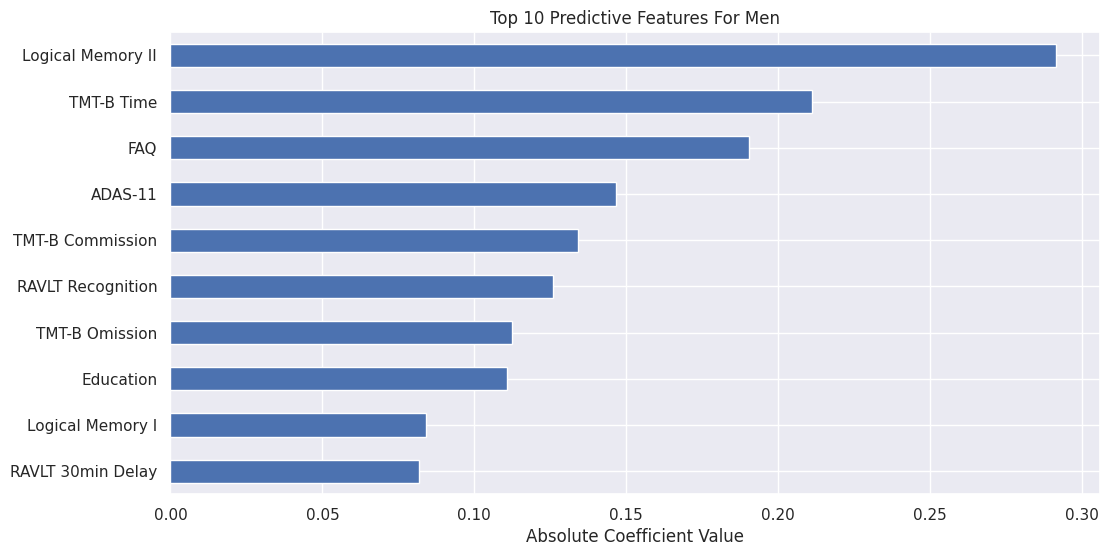

In [58]:
import matplotlib.pyplot as plt

# Get feature importance and take absolute value
fi = run_men1["feature_importance"].abs()

# Rename feature labels (only those listed will change)
rename_dict = {
    "Logical_MEM_delay" : "Logical Memory II",
    "Trail_B_Time": "TMT-B Time",
    "FAQ_Score" : "FAQ",
    "ADAS_Score": "ADAS-11",
    "Trail_B_Comm": "TMT-B Commission",
    "AVRECOGTOT" : "RAVLT Recognition",
    "Trail_B_Omm" : "TMT-B Omission",
    "Logical_MEM_imm" : "Logical Memory I",
    "AVDEL30MIN" : "RAVLT 30min Delay",
  
    # add more if needed
}

fi = fi.rename(index=rename_dict)

# Select top 10 features (largest absolute coefficients)
top10 = fi.sort_values(ascending=False).head(10)

# Sort ascending for horizontal bar plot (largest bar on top)
top10_sorted = top10.sort_values(ascending=True)
# Plot horizontal bar chart
plt.figure(figsize=(12, 6))
top10_sorted.plot(kind="barh")
plt.title("Top 10 Predictive Features For Men")
plt.xlabel("Absolute Coefficient Value")
#plt.ylabel("Features")
plt.show()


In [59]:
misclassified_df_men1 = run_men1["X_test_df"]
misclassified_df_men1


misclassified_df_men1.to_csv("/home/xlajoie/Desktop/PhD/misclassified_subjects_men1_MCI_AD.csv", index = False)

misclassified_df_men1

,Education,Race,Age_Cognition,ADAS_Score,CDR_Score,FAQ_Score,GDS_Score,MMSE_Score,Logical_MEM_imm,Logical_MEM_delay,...,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL,True_Label,Predicted_Label,Misclassified
0,12,0,78.176591,7.00,0.5,0,3,27,8,9,...,43,0,0,84,0,0,27,0,0,False
1,18,0,82.505133,25.00,0.5,6,2,24,2,1,...,37,0,0,208,5,0,21,1,1,False
2,12,0,61.853525,21.33,0.5,4,2,29,8,3,...,57,0,0,-1,1,0,23,0,1,True
3,20,0,76.339494,6.00,0.5,0,2,26,6,6,...,43,1,0,99,1,0,25,0,0,False
4,17,0,74.269678,8.67,0.5,1,1,29,9,5,...,44,0,0,80,0,0,30,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,17,0,75.436003,10.00,0.5,5,0,29,5,3,...,44,0,0,156,2,0,29,0,1,True
87,16,0,73.645448,8.00,0.5,0,0,30,7,5,...,38,0,0,71,0,0,29,0,0,False
88,19,0,56.024641,11.00,0.5,15,4,30,10,5,...,62,0,0,258,1,0,30,0,1,True
89,16,0,75.373032,15.00,0.5,0,1,27,2,0,...,32,0,0,103,0,0,21,1,1,False


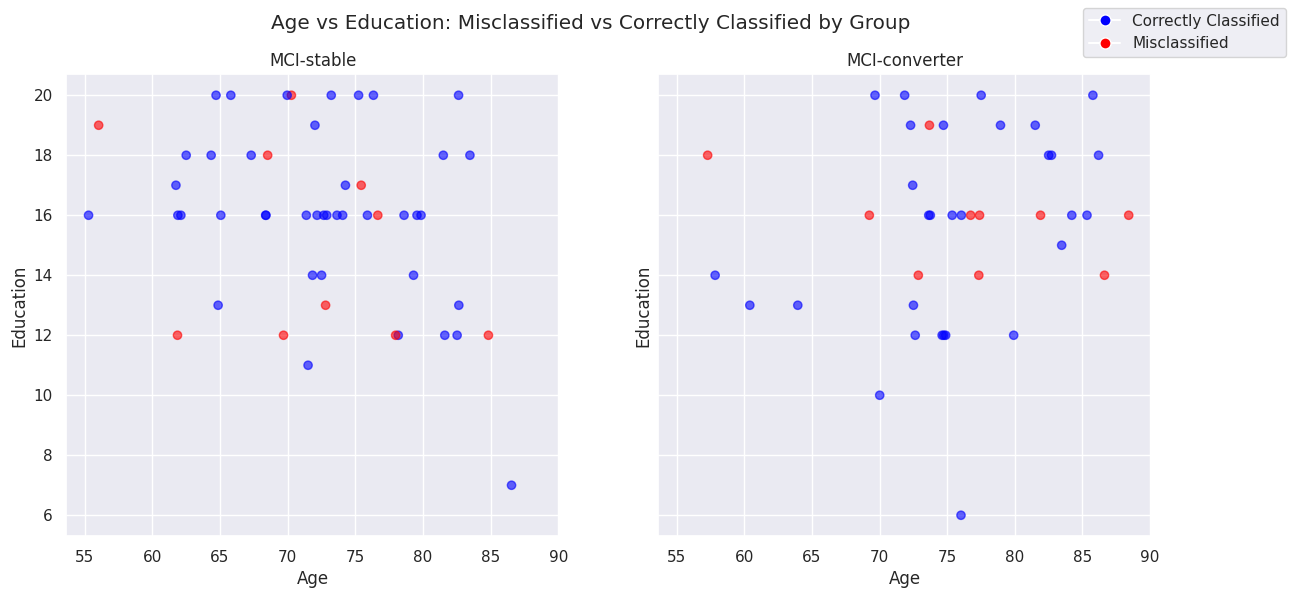

In [60]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Use the full test set from the function output
X_test_df = run_men1["X_test_df"]

# Separate the two groups
group0 = X_test_df[X_test_df['True_Label'] == 0]  # MCI-stable
group1 = X_test_df[X_test_df['True_Label'] == 1]  # MCI-converter

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharex=True, sharey=True)

colors = {True: 'red', False: 'blue'}

# MCI-stable
axes[0].scatter(group0['Age_Cognition'], group0['Education'], 
                c=group0['Misclassified'].map(colors), alpha=0.6)
axes[0].set_title("MCI-stable")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Education")

# MCI-converter
axes[1].scatter(group1['Age_Cognition'], group1['Education'], 
                c=group1['Misclassified'].map(colors), alpha=0.6)
axes[1].set_title("MCI-converter")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Education")

# Shared legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Correctly Classified', 
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Misclassified', 
           markerfacecolor='red', markersize=8)
]
fig.legend(handles=legend_elements, loc='upper right')

plt.suptitle("Age vs Education: Misclassified vs Correctly Classified by Group")
plt.show()

In [ ]:
#permutation test on the ml model's accuracy to determine whether the classifier's performance is significantly better than chance

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.utils import shuffle

# Assume you already have your real accuracy
results = run_men
real_accuracy = results["acc_test"]
print(f"Observed accuracy: {real_accuracy:.4f}")

# Permutation test
n_permutations = 1000
perm_accuracies = []

for _ in range(n_permutations):
    y_permuted = shuffle(y, random_state=None)
    
    # Split with same method as in your function
    X_train, X_test, y_train, y_test = train_test_split(
        x, y_permuted, test_size=0.2, stratify=y_permuted, shuffle=True, random_state=123
    )
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LinearSVC(max_iter=10000))
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    perm_accuracies.append(acc)

# Compute permutation p-value
perm_accuracies = np.array(perm_accuracies)
p_value = np.mean(perm_accuracies >= real_accuracy)

print(f"Permutation p-value: {p_value:.4f}")

# 2. classification only composite scores 

In [61]:
df_men.columns

Index(['RID', 'Groupe', 'Education', 'Race', 'Age_Cognition', 'PHC_MEM',
       'PHC_EXF', 'PHC_LAN', 'PHC_VSP', 'ADAS_Score', 'CDR_Score', 'FAQ_Score',
       'GDS_Score', 'MMSE_Score', 'Logical_MEM_imm', 'Logical_MEM_delay',
       'CLOCKSCOR', 'COPYSCOR', 'AVLT_Total', 'AVDEL30MIN', 'AVRECOGTOT',
       'Animals_Total', 'Animals_Pers', 'Animals_Intru', 'Trail_A_Time',
       'Trail_A_Comm', 'Trail_A_Omm', 'Trail_B_Time', 'Trail_B_Comm',
       'Trail_B_Omm', 'BNTTOTAL'],
      dtype='object')

In [62]:
df_men2 = df_men.drop(columns=['ADAS_Score', 'CDR_Score', 'FAQ_Score',
       'GDS_Score', 'MMSE_Score', 'Logical_MEM_imm', 'Logical_MEM_delay',
       'CLOCKSCOR', 'COPYSCOR', 'AVLT_Total', 'AVDEL30MIN', 'AVRECOGTOT',
       'Animals_Total', 'Animals_Pers', 'Animals_Intru', 'Trail_A_Time',
       'Trail_A_Comm', 'Trail_A_Omm', 'Trail_B_Time', 'Trail_B_Comm',
       'Trail_B_Omm', 'BNTTOTAL'])

In [63]:
df_men2

,RID,Groupe,Education,Race,Age_Cognition,PHC_MEM,PHC_EXF,PHC_LAN,PHC_VSP
0,33,0,20,0,83.523614,-0.332,0.257,0.045,0.963
1,38,0,12,0,76.952772,-0.002,-0.594,0.411,0.264
2,42,1,18,0,72.941821,0.047,0.926,0.816,0.963
3,45,1,18,0,86.195756,-0.351,-0.052,0.272,0.264
4,50,1,16,0,77.754962,-0.192,-1.059,0.163,-0.861
...,...,...,...,...,...,...,...,...,...
448,5000,0,18,0,76.799452,-0.165,-0.418,-0.303,-0.041
449,5004,0,20,0,64.703628,0.580,0.744,0.858,0.963
450,5007,0,14,0,71.835729,0.456,-0.303,-0.355,-0.383
451,5014,0,16,0,76.662560,0.275,-0.142,0.283,0.264


In [64]:
x_men2 = df_men2.drop(["RID", "Groupe"], axis =1)
y_men2 = df_men2["Groupe"].to_numpy()

In [65]:
run_men2 = machine_learning(x_men2,y_men2)
run_men2



PHC_MEM         -0.297562
PHC_EXF         -0.109148
Education        0.083880
PHC_VSP          0.080234
Race            -0.062224
Age_Cognition   -0.031849
PHC_LAN         -0.005393
dtype: float64


{'len_X_train': 362,
 'len_X_test': 91,
 'cv_scores': array([0.54054054, 0.51351351, 0.66666667, 0.55555556, 0.66666667,
        0.75      , 0.66666667, 0.61111111, 0.58333333, 0.58333333]),
 'cv_mean': 0.6137387387387386,
 'cv_std': 0.06900395971512269,
 'confusion_matrix': Predicted class  MCI_stable  MCI_convert
 Actual class                            
 MCI_stable               40           11
 MCI_convert              13           27,
 'acc_test': 0.7362637362637363,
 'acc_train': 0.6325966850828729,
 'auc': 0.7906862745098039,
 'pipeline': Pipeline(steps=[('scaler', StandardScaler()),
                 ('clf', LinearSVC(max_iter=10000))]),
 'X_test_df':     Education  Race  Age_Cognition  PHC_MEM  PHC_EXF  PHC_LAN  PHC_VSP  \
 0          12     0      78.176591    0.130    0.729    0.325   -0.305   
 1          18     0      82.505133   -0.576   -0.353   -0.336   -0.237   
 2          12     0      61.853525   -0.366    0.191   -0.477   -0.632   
 3          20     0      76.33949

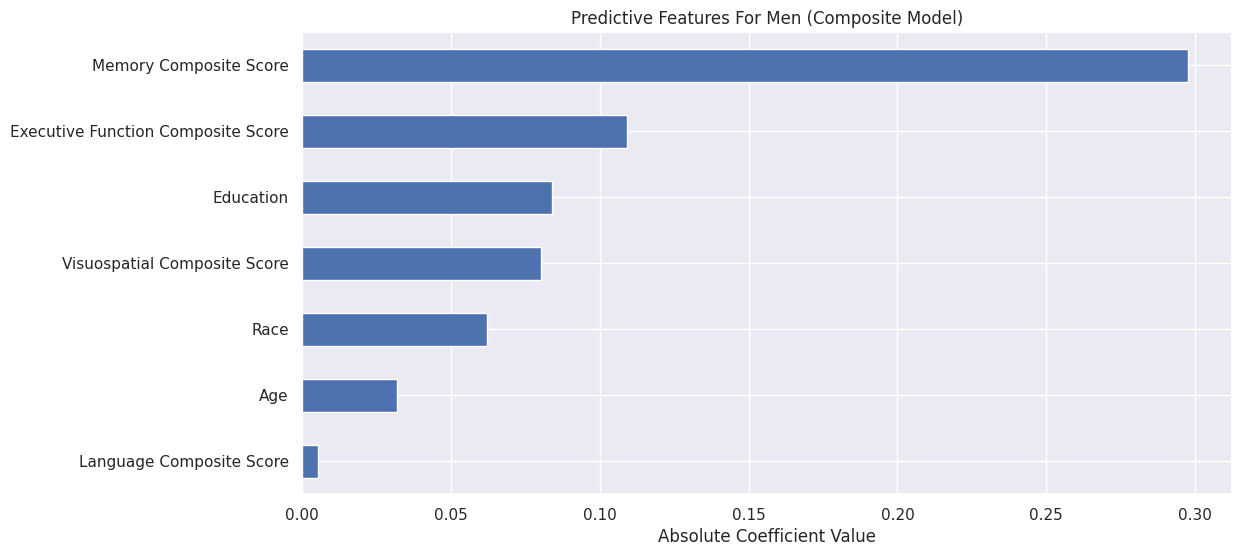

In [66]:
import matplotlib.pyplot as plt

# Get feature importance and take absolute value
fi = run_men2["feature_importance"].abs()

rename_dict = {
    "PHC_MEM": "Memory Composite Score",
    "PHC_VSP": "Visuospatial Composite Score",
    "PHC_EXF": "Executive Function Composite Score",
    "Age_Cognition": "Age",
    "PHC_LAN": "Language Composite Score",
    # add more if needed
}

fi = fi.rename(index=rename_dict)

# Sort from lowest to highest so the largest bar is at the top
fi_sorted = fi.sort_values(ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(12, 6))
fi_sorted.plot(kind="barh")
plt.title("Predictive Features For Men (Composite Model)")
plt.xlabel("Absolute Coefficient Value")
#plt.ylabel("Features")
plt.show()

In [67]:
misclassified_df_men2 = run_men2["X_test_df"]
misclassified_df_men2


misclassified_df_men2.to_csv("/home/xlajoie/Desktop/PhD/misclassified_subjects_men2_MCI_AD.csv", index = False)

misclassified_df_men2

,Education,Race,Age_Cognition,PHC_MEM,PHC_EXF,PHC_LAN,PHC_VSP,True_Label,Predicted_Label,Misclassified
0,12,0,78.176591,0.130,0.729,0.325,-0.305,0,0,False
1,18,0,82.505133,-0.576,-0.353,-0.336,-0.237,1,1,False
2,12,0,61.853525,-0.366,0.191,-0.477,-0.632,0,0,False
3,20,0,76.339494,-0.080,0.457,0.223,0.483,0,1,True
4,17,0,74.269678,0.208,0.313,0.293,0.963,0,0,False
...,...,...,...,...,...,...,...,...,...,...
86,17,0,75.436003,-0.262,0.155,0.301,0.264,0,1,True
87,16,0,73.645448,0.167,0.921,1.131,0.963,0,0,False
88,19,0,56.024641,0.068,0.310,0.784,0.264,0,1,True
89,16,0,75.373032,-0.301,0.558,-0.684,0.963,1,1,False


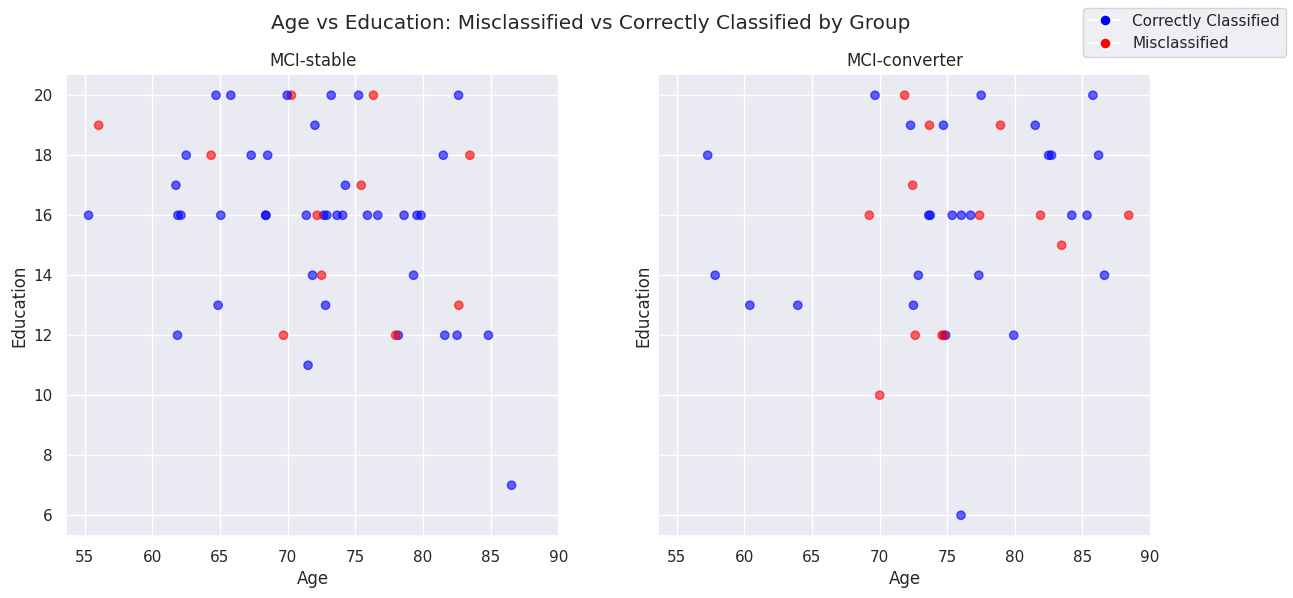

In [68]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Use the full test set from the function output
X_test_df = run_men2["X_test_df"]

# Separate the two groups
group0 = X_test_df[X_test_df['True_Label'] == 0]  # MCI-stable
group1 = X_test_df[X_test_df['True_Label'] == 1]  # MCI-converter

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharex=True, sharey=True)

colors = {True: 'red', False: 'blue'}

# MCI-stable
axes[0].scatter(group0['Age_Cognition'], group0['Education'], 
                c=group0['Misclassified'].map(colors), alpha=0.6)
axes[0].set_title("MCI-stable")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Education")

# MCI-converter
axes[1].scatter(group1['Age_Cognition'], group1['Education'], 
                c=group1['Misclassified'].map(colors), alpha=0.6)
axes[1].set_title("MCI-converter")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Education")

# Shared legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Correctly Classified', 
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Misclassified', 
           markerfacecolor='red', markersize=8)
]
fig.legend(handles=legend_elements, loc='upper right')

plt.suptitle("Age vs Education: Misclassified vs Correctly Classified by Group")
plt.show()

# Classification femmes 

In [69]:
df = pd.read_csv("/home/xlajoie/Documents/df_cogn_MCI_AD_new.csv")
df

,RID,Sex,Groupe,Education,Ethnicity,Race,Age_Cognition,Diagnosis,PHC_MEM,PHC_MEM_SE,...,Veg_Intru,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL,Race_binary,Race_matrix
0,6,2,1,13,2.0,5,80.495551,2,-0.246,0.170,...,0.0,49,0,0,168,1,0,25,1,White
1,30,2,2,19,2.0,5,80.052019,2,-0.077,0.168,...,0.0,47,0,0,139,0,0,21,1,White
2,33,1,1,20,2.0,5,83.523614,2,-0.332,0.153,...,0.0,34,0,0,-1,-1,-1,27,1,White
3,38,1,1,12,2.0,5,76.952772,2,-0.002,0.172,...,0.0,61,0,0,300,1,10,26,1,White
4,41,2,2,14,2.0,5,71.036277,2,-0.928,0.156,...,0.0,18,0,0,145,2,0,29,1,White
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758,5031,2,2,14,1.0,5,80.605065,2,-0.198,0.178,...,NaN,31,0,0,73,1,0,18,1,White
759,5047,2,1,16,2.0,3,69.004791,2,0.005,0.152,...,NaN,28,0,0,66,0,0,26,2,NonWhite
760,5066,1,1,17,2.0,5,79.942505,2,0.573,0.172,...,NaN,50,0,0,156,1,0,26,1,White
761,5099,2,1,16,2.0,5,61.694730,2,0.480,0.184,...,NaN,59,0,0,98,0,0,29,1,White


In [70]:
# drop men subjects 

In [71]:
df_women = df[df["Sex"] == 2].copy()
df_women

,RID,Sex,Groupe,Education,Ethnicity,Race,Age_Cognition,Diagnosis,PHC_MEM,PHC_MEM_SE,...,Veg_Intru,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL,Race_binary,Race_matrix
0,6,2,1,13,2.0,5,80.495551,2,-0.246,0.170,...,0.0,49,0,0,168,1,0,25,1,White
1,30,2,2,19,2.0,5,80.052019,2,-0.077,0.168,...,0.0,47,0,0,139,0,0,21,1,White
4,41,2,2,14,2.0,5,71.036277,2,-0.928,0.156,...,0.0,18,0,0,145,2,0,29,1,White
6,44,2,1,16,2.0,5,85.998631,2,-0.480,0.173,...,0.0,26,0,0,90,1,0,24,1,White
10,54,2,2,20,2.0,5,81.207392,2,-0.790,0.170,...,0.0,38,0,0,201,1,0,23,1,White
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,5026,2,2,18,2.0,5,70.666667,2,1.099,0.211,...,NaN,41,0,0,136,0,0,24,1,White
758,5031,2,2,14,1.0,5,80.605065,2,-0.198,0.178,...,NaN,31,0,0,73,1,0,18,1,White
759,5047,2,1,16,2.0,3,69.004791,2,0.005,0.152,...,NaN,28,0,0,66,0,0,26,2,NonWhite
761,5099,2,1,16,2.0,5,61.694730,2,0.480,0.184,...,NaN,59,0,0,98,0,0,29,1,White


In [72]:
df_women = df_women.drop(columns=["Sex", 'Diagnosis','Ethnicity', 'PHC_MEM_SE', 'PHC_EXF_SE',
                          'PHC_LAN_SE', 'PHC_VSP_SE','MoCA_Score', 'Veg_Total', 'Veg_Pers', 'Veg_Intru', 'ECOG_Score', 'Anxiety_Score', 'DSPANFOR', 
                          'DSPANFLTH','DSPANBAC','DSPANBLTH', 'Veg_Total', 'Veg_Pers','Veg_Intru', 'Race_binary', 'Race_matrix'])

df_women

,RID,Groupe,Education,Race,Age_Cognition,PHC_MEM,PHC_EXF,PHC_LAN,PHC_VSP,ADAS_Score,...,Animals_Total,Animals_Pers,Animals_Intru,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL
0,6,1,13,5,80.495551,-0.246,-0.200,0.065,-0.237,18.67,...,13,4,0,49,0,0,168,1,0,25
1,30,2,19,5,80.052019,-0.077,0.042,0.180,0.963,10.00,...,16,3,0,47,0,0,139,0,0,21
4,41,2,14,5,71.036277,-0.928,0.719,0.865,0.264,18.33,...,18,7,0,18,0,0,145,2,0,29
6,44,1,16,5,85.998631,-0.480,0.730,-0.092,0.963,17.00,...,15,3,0,26,0,0,90,1,0,24
10,54,2,20,5,81.207392,-0.790,-0.546,0.180,0.258,20.33,...,13,4,0,38,0,0,201,1,0,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,5026,2,18,5,70.666667,1.099,-0.190,0.206,0.963,5.00,...,15,0,0,41,0,0,136,0,0,24
758,5031,2,14,5,80.605065,-0.198,-0.305,-0.706,-0.094,9.00,...,8,0,0,31,0,0,73,1,0,18
759,5047,1,16,3,69.004791,0.005,0.839,0.288,0.963,10.00,...,13,1,0,28,0,0,66,0,0,26
761,5099,1,16,5,61.694730,0.480,0.192,0.944,0.264,9.00,...,22,0,0,59,0,0,98,0,0,29


In [73]:
df_women.isnull().sum(axis = 0)

RID                  0
Groupe               0
Education            0
Race                 0
Age_Cognition        0
PHC_MEM              0
PHC_EXF              0
PHC_LAN              0
PHC_VSP              0
ADAS_Score           0
CDR_Score            0
FAQ_Score            0
GDS_Score            0
MMSE_Score           0
Logical_MEM_imm      0
Logical_MEM_delay    0
CLOCKSCOR            0
COPYSCOR             0
AVLT_Total           0
AVDEL30MIN           0
AVRECOGTOT           0
Animals_Total        0
Animals_Pers         0
Animals_Intru        0
Trail_A_Time         0
Trail_A_Comm         0
Trail_A_Omm          0
Trail_B_Time         0
Trail_B_Comm         0
Trail_B_Omm          0
BNTTOTAL             0
dtype: int64

In [74]:
df_women

,RID,Groupe,Education,Race,Age_Cognition,PHC_MEM,PHC_EXF,PHC_LAN,PHC_VSP,ADAS_Score,...,Animals_Total,Animals_Pers,Animals_Intru,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL
0,6,1,13,5,80.495551,-0.246,-0.200,0.065,-0.237,18.67,...,13,4,0,49,0,0,168,1,0,25
1,30,2,19,5,80.052019,-0.077,0.042,0.180,0.963,10.00,...,16,3,0,47,0,0,139,0,0,21
4,41,2,14,5,71.036277,-0.928,0.719,0.865,0.264,18.33,...,18,7,0,18,0,0,145,2,0,29
6,44,1,16,5,85.998631,-0.480,0.730,-0.092,0.963,17.00,...,15,3,0,26,0,0,90,1,0,24
10,54,2,20,5,81.207392,-0.790,-0.546,0.180,0.258,20.33,...,13,4,0,38,0,0,201,1,0,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,5026,2,18,5,70.666667,1.099,-0.190,0.206,0.963,5.00,...,15,0,0,41,0,0,136,0,0,24
758,5031,2,14,5,80.605065,-0.198,-0.305,-0.706,-0.094,9.00,...,8,0,0,31,0,0,73,1,0,18
759,5047,1,16,3,69.004791,0.005,0.839,0.288,0.963,10.00,...,13,1,0,28,0,0,66,0,0,26
761,5099,1,16,5,61.694730,0.480,0.192,0.944,0.264,9.00,...,22,0,0,59,0,0,98,0,0,29


In [75]:
df_women["Race"] = df_women["Race"].apply(lambda x: 0 if x == 5 else 1)
df_women

,RID,Groupe,Education,Race,Age_Cognition,PHC_MEM,PHC_EXF,PHC_LAN,PHC_VSP,ADAS_Score,...,Animals_Total,Animals_Pers,Animals_Intru,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL
0,6,1,13,0,80.495551,-0.246,-0.200,0.065,-0.237,18.67,...,13,4,0,49,0,0,168,1,0,25
1,30,2,19,0,80.052019,-0.077,0.042,0.180,0.963,10.00,...,16,3,0,47,0,0,139,0,0,21
4,41,2,14,0,71.036277,-0.928,0.719,0.865,0.264,18.33,...,18,7,0,18,0,0,145,2,0,29
6,44,1,16,0,85.998631,-0.480,0.730,-0.092,0.963,17.00,...,15,3,0,26,0,0,90,1,0,24
10,54,2,20,0,81.207392,-0.790,-0.546,0.180,0.258,20.33,...,13,4,0,38,0,0,201,1,0,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,5026,2,18,0,70.666667,1.099,-0.190,0.206,0.963,5.00,...,15,0,0,41,0,0,136,0,0,24
758,5031,2,14,0,80.605065,-0.198,-0.305,-0.706,-0.094,9.00,...,8,0,0,31,0,0,73,1,0,18
759,5047,1,16,1,69.004791,0.005,0.839,0.288,0.963,10.00,...,13,1,0,28,0,0,66,0,0,26
761,5099,1,16,0,61.694730,0.480,0.192,0.944,0.264,9.00,...,22,0,0,59,0,0,98,0,0,29


In [76]:
df_women["Groupe"] = df_women["Groupe"].apply(lambda x: 0 if x == 1 else 1)
df_women

,RID,Groupe,Education,Race,Age_Cognition,PHC_MEM,PHC_EXF,PHC_LAN,PHC_VSP,ADAS_Score,...,Animals_Total,Animals_Pers,Animals_Intru,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL
0,6,0,13,0,80.495551,-0.246,-0.200,0.065,-0.237,18.67,...,13,4,0,49,0,0,168,1,0,25
1,30,1,19,0,80.052019,-0.077,0.042,0.180,0.963,10.00,...,16,3,0,47,0,0,139,0,0,21
4,41,1,14,0,71.036277,-0.928,0.719,0.865,0.264,18.33,...,18,7,0,18,0,0,145,2,0,29
6,44,0,16,0,85.998631,-0.480,0.730,-0.092,0.963,17.00,...,15,3,0,26,0,0,90,1,0,24
10,54,1,20,0,81.207392,-0.790,-0.546,0.180,0.258,20.33,...,13,4,0,38,0,0,201,1,0,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,5026,1,18,0,70.666667,1.099,-0.190,0.206,0.963,5.00,...,15,0,0,41,0,0,136,0,0,24
758,5031,1,14,0,80.605065,-0.198,-0.305,-0.706,-0.094,9.00,...,8,0,0,31,0,0,73,1,0,18
759,5047,0,16,1,69.004791,0.005,0.839,0.288,0.963,10.00,...,13,1,0,28,0,0,66,0,0,26
761,5099,0,16,0,61.694730,0.480,0.192,0.944,0.264,9.00,...,22,0,0,59,0,0,98,0,0,29


In [77]:
df_women.to_csv("/data/brambati/Xanthy/ADNI/df_women.csv", index=False)

In [78]:
from scipy.stats import ttest_ind

# Separate the groups
group_stable = df_women[df_women["Groupe"] == 0]
group_converters = df_women[df_women["Groupe"] == 1]

# T-test for Age
t_age, p_age = ttest_ind(group_stable["Age_Cognition"], group_converters["Age_Cognition"], equal_var=False)

# T-test for Education
t_edu, p_edu = ttest_ind(group_stable["Education"], group_converters["Education"], equal_var=False)

print(f"T-test for Age: t = {t_age:.3f}, p = {p_age:.4f}")
print(f"T-test for Education: t = {t_edu:.3f}, p = {p_edu:.4f}")

T-test for Age: t = -0.762, p = 0.4466
T-test for Education: t = 0.036, p = 0.9714


In [79]:
# Group by 'Groupe' and calculate mean and std for Age and Education
demographic_stats_women = df_women.groupby("Groupe")[["Age_Cognition", "Education"]].agg(["mean", "std", "count"])

# Rename index if you want clearer labels
demographic_stats_women.index = ["MCI-stable", "MCI-converter"]

print(demographic_stats_women)

              Age_Cognition                  Education                
                       mean       std count       mean       std count
MCI-stable        72.246815  7.774450   181  15.337017  2.894863   181
MCI-converter     72.914485  7.477675   129  15.325581  2.666818   129


In [80]:
df_women = pd.read_csv("/data/brambati/Xanthy/ADNI/df_women.csv")
df_women

,RID,Groupe,Education,Race,Age_Cognition,PHC_MEM,PHC_EXF,PHC_LAN,PHC_VSP,ADAS_Score,...,Animals_Total,Animals_Pers,Animals_Intru,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL
0,6,0,13,0,80.495551,-0.246,-0.200,0.065,-0.237,18.67,...,13,4,0,49,0,0,168,1,0,25
1,30,1,19,0,80.052019,-0.077,0.042,0.180,0.963,10.00,...,16,3,0,47,0,0,139,0,0,21
2,41,1,14,0,71.036277,-0.928,0.719,0.865,0.264,18.33,...,18,7,0,18,0,0,145,2,0,29
3,44,0,16,0,85.998631,-0.480,0.730,-0.092,0.963,17.00,...,15,3,0,26,0,0,90,1,0,24
4,54,1,20,0,81.207392,-0.790,-0.546,0.180,0.258,20.33,...,13,4,0,38,0,0,201,1,0,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,5026,1,18,0,70.666667,1.099,-0.190,0.206,0.963,5.00,...,15,0,0,41,0,0,136,0,0,24
306,5031,1,14,0,80.605065,-0.198,-0.305,-0.706,-0.094,9.00,...,8,0,0,31,0,0,73,1,0,18
307,5047,0,16,1,69.004791,0.005,0.839,0.288,0.963,10.00,...,13,1,0,28,0,0,66,0,0,26
308,5099,0,16,0,61.694730,0.480,0.192,0.944,0.264,9.00,...,22,0,0,59,0,0,98,0,0,29


# 1. classify without composite scores

In [81]:
df_women1 = df_women.drop(columns=['PHC_MEM', 'PHC_EXF', 'PHC_LAN', 'PHC_VSP'])
df_women1

,RID,Groupe,Education,Race,Age_Cognition,ADAS_Score,CDR_Score,FAQ_Score,GDS_Score,MMSE_Score,...,Animals_Total,Animals_Pers,Animals_Intru,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL
0,6,0,13,0,80.495551,18.67,0.5,0,0,25,...,13,4,0,49,0,0,168,1,0,25
1,30,1,19,0,80.052019,10.00,0.5,6,1,29,...,16,3,0,47,0,0,139,0,0,21
2,41,1,14,0,71.036277,18.33,0.5,4,2,25,...,18,7,0,18,0,0,145,2,0,29
3,44,0,16,0,85.998631,17.00,0.5,4,4,26,...,15,3,0,26,0,0,90,1,0,24
4,54,1,20,0,81.207392,20.33,0.5,12,2,27,...,13,4,0,38,0,0,201,1,0,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,5026,1,18,0,70.666667,5.00,0.5,0,1,30,...,15,0,0,41,0,0,136,0,0,24
306,5031,1,14,0,80.605065,9.00,0.5,9,1,25,...,8,0,0,31,0,0,73,1,0,18
307,5047,0,16,1,69.004791,10.00,0.5,0,1,30,...,13,1,0,28,0,0,66,0,0,26
308,5099,0,16,0,61.694730,9.00,0.5,4,2,28,...,22,0,0,59,0,0,98,0,0,29


In [82]:
x_women1 = df_women1.drop(["RID", "Groupe"], axis =1)
y_women1 = df_women1["Groupe"].to_numpy()

In [83]:
run_women1 = machine_learning(x_women1,y_women1)
run_women1

FAQ_Score            0.262602
Logical_MEM_delay   -0.179967
ADAS_Score           0.147855
Animals_Total       -0.139594
Age_Cognition       -0.131317
Race                -0.126611
Education            0.124753
Trail_B_Time         0.118122
AVLT_Total          -0.109299
MMSE_Score          -0.091787
Trail_A_Time        -0.089545
AVDEL30MIN          -0.083357
Logical_MEM_imm      0.081583
CLOCKSCOR           -0.073427
BNTTOTAL             0.065875
Trail_A_Comm        -0.060388
Trail_B_Omm         -0.052443
Trail_B_Comm        -0.044832
CDR_Score            0.041693
COPYSCOR            -0.039956
GDS_Score           -0.038472
AVRECOGTOT          -0.027077
Trail_A_Omm          0.009696
Animals_Pers        -0.009392
Animals_Intru        0.001882
dtype: float64


{'len_X_train': 248,
 'len_X_test': 62,
 'cv_scores': array([0.88, 0.76, 0.68, 0.84, 0.72, 0.68, 0.68, 0.6 , 0.75, 0.75]),
 'cv_mean': 0.734,
 'cv_std': 0.07787168933572713,
 'confusion_matrix': Predicted class  MCI_stable  MCI_convert
 Actual class                            
 MCI_stable               28            8
 MCI_convert               7           19,
 'acc_test': 0.7580645161290323,
 'acc_train': 0.782258064516129,
 'auc': 0.8418803418803419,
 'pipeline': Pipeline(steps=[('scaler', StandardScaler()),
                 ('clf', LinearSVC(max_iter=10000))]),
 'X_test_df':     Education  Race  Age_Cognition  ADAS_Score  CDR_Score  FAQ_Score  \
 0          12     0      87.934292        5.00        0.5          0   
 1          14     0      68.339494        9.00        0.5          0   
 2          14     0      69.040383        6.00        0.5          0   
 3          12     0      83.745380       12.33        0.5          0   
 4          14     0      83.474333       15.67    

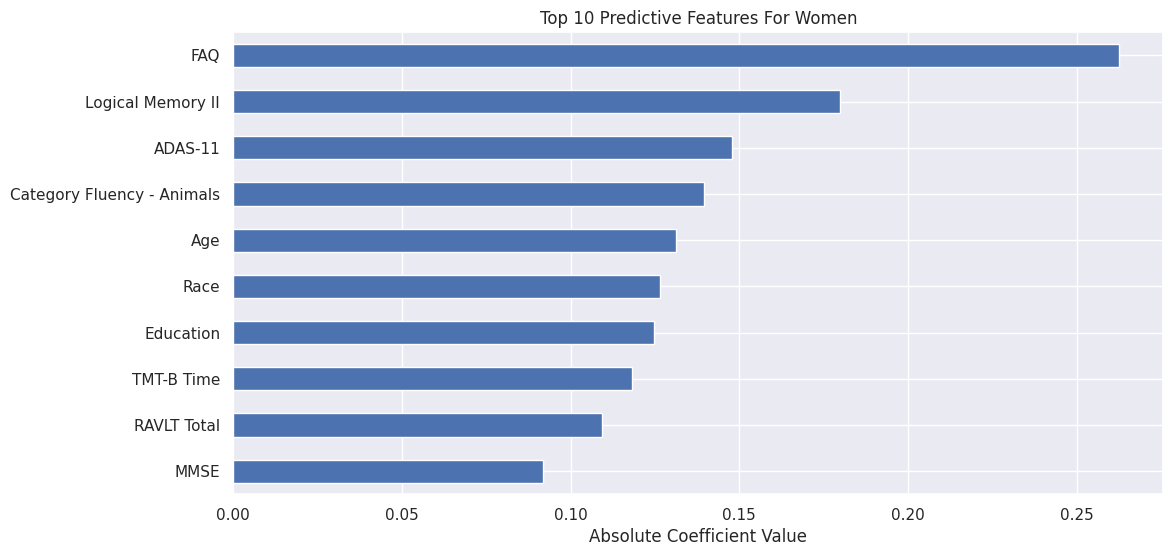

In [84]:
import matplotlib.pyplot as plt

# Get feature importance and take absolute value
fi = run_women1["feature_importance"].abs()


# Rename feature labels
rename_dict = {
    "FAQ_Score" : "FAQ",
    "Logical_MEM_delay" : "Logical Memory II",
    "ADAS_Score": "ADAS-11",
    "Animals_Total" : "Category Fluency - Animals",
    "Age_Cognition" : "Age",
    "Trail_B_Time": "TMT-B Time",
    "AVLT_Total" : "RAVLT Total",
    "MMSE_Score" : "MMSE"
}

fi = fi.rename(index=rename_dict)

# Select top 10 features (largest absolute coefficients)
top10 = fi.sort_values(ascending=False).head(10)

# Sort ascending for horizontal bar plot (largest bar on top)
top10_sorted = top10.sort_values(ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(12, 6))
top10_sorted.plot(kind="barh")
plt.title("Top 10 Predictive Features For Women")
plt.xlabel("Absolute Coefficient Value")
#plt.ylabel("Features")
plt.show()

In [85]:
misclassified_df_women1 = run_women1["X_test_df"]
misclassified_df_women1


misclassified_df_women1.to_csv("/home/xlajoie/Desktop/PhD/misclassified_subjects_women1_MCI_AD.csv", index = False)

misclassified_df_women1

,Education,Race,Age_Cognition,ADAS_Score,CDR_Score,FAQ_Score,GDS_Score,MMSE_Score,Logical_MEM_imm,Logical_MEM_delay,...,Trail_A_Time,Trail_A_Comm,Trail_A_Omm,Trail_B_Time,Trail_B_Comm,Trail_B_Omm,BNTTOTAL,True_Label,Predicted_Label,Misclassified
0,12,0,87.934292,5.00,0.5,0,0,25,10,9,...,42,0,0,124,1,0,25,0,0,False
1,14,0,68.339494,9.00,0.5,0,2,30,11,8,...,49,0,0,100,0,0,30,0,0,False
2,14,0,69.040383,6.00,0.5,0,0,27,10,9,...,33,0,0,69,0,0,30,1,0,True
3,12,0,83.745380,12.33,0.5,0,4,26,6,3,...,75,1,1,125,3,2,24,0,0,False
4,14,0,83.474333,15.67,0.5,4,4,25,3,1,...,52,0,0,160,4,0,20,1,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,17,0,68.596851,2.00,0.5,0,2,30,15,11,...,16,0,0,37,0,0,30,0,0,False
58,16,0,84.698152,15.00,0.5,1,0,29,4,0,...,59,0,0,240,1,0,23,1,1,False
59,18,1,65.768652,3.00,0.5,1,2,30,11,8,...,13,0,0,74,1,0,26,0,0,False
60,12,0,65.886379,12.00,0.5,3,1,28,5,1,...,22,0,0,68,1,0,30,0,0,False


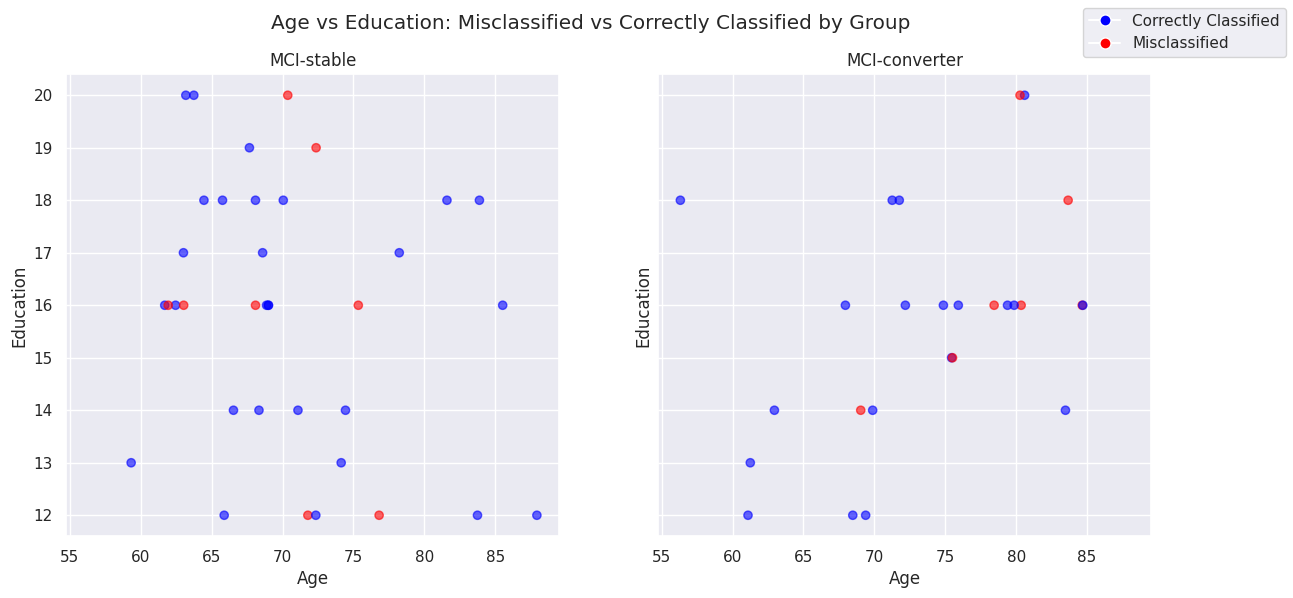

In [86]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Use the full test set from the function output
X_test_df = run_women1["X_test_df"]

# Separate the two groups
group0 = X_test_df[X_test_df['True_Label'] == 0]  # MCI-stable
group1 = X_test_df[X_test_df['True_Label'] == 1]  # MCI-converter

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharex=True, sharey=True)

colors = {True: 'red', False: 'blue'}

# MCI-stable
axes[0].scatter(group0['Age_Cognition'], group0['Education'], 
                c=group0['Misclassified'].map(colors), alpha=0.6)
axes[0].set_title("MCI-stable")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Education")

# MCI-converter
axes[1].scatter(group1['Age_Cognition'], group1['Education'], 
                c=group1['Misclassified'].map(colors), alpha=0.6)
axes[1].set_title("MCI-converter")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Education")

# Shared legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Correctly Classified', 
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Misclassified', 
           markerfacecolor='red', markersize=8)
]
fig.legend(handles=legend_elements, loc='upper right')

plt.suptitle("Age vs Education: Misclassified vs Correctly Classified by Group")
plt.show()

# 2. classification women only composite scores + demographs

In [87]:
df_women2 = df_women.drop(columns=['ADAS_Score', 'CDR_Score', 'FAQ_Score',
       'GDS_Score', 'MMSE_Score', 'Logical_MEM_imm', 'Logical_MEM_delay',
       'CLOCKSCOR', 'COPYSCOR', 'AVLT_Total', 'AVDEL30MIN', 'AVRECOGTOT',
       'Animals_Total', 'Animals_Pers', 'Animals_Intru', 'Trail_A_Time',
       'Trail_A_Comm', 'Trail_A_Omm', 'Trail_B_Time', 'Trail_B_Comm',
       'Trail_B_Omm', 'BNTTOTAL'])

df_women2

,RID,Groupe,Education,Race,Age_Cognition,PHC_MEM,PHC_EXF,PHC_LAN,PHC_VSP
0,6,0,13,0,80.495551,-0.246,-0.200,0.065,-0.237
1,30,1,19,0,80.052019,-0.077,0.042,0.180,0.963
2,41,1,14,0,71.036277,-0.928,0.719,0.865,0.264
3,44,0,16,0,85.998631,-0.480,0.730,-0.092,0.963
4,54,1,20,0,81.207392,-0.790,-0.546,0.180,0.258
...,...,...,...,...,...,...,...,...,...
305,5026,1,18,0,70.666667,1.099,-0.190,0.206,0.963
306,5031,1,14,0,80.605065,-0.198,-0.305,-0.706,-0.094
307,5047,0,16,1,69.004791,0.005,0.839,0.288,0.963
308,5099,0,16,0,61.694730,0.480,0.192,0.944,0.264


In [88]:
x_women2 = df_women2.drop(["RID", "Groupe"], axis =1)
y_women2 = df_women2["Groupe"].to_numpy()

In [89]:
run_women2 = machine_learning(x_women2,y_women2)
run_women2

PHC_MEM         -0.595117
Education        0.130747
Race            -0.125413
Age_Cognition   -0.117373
PHC_EXF         -0.081507
PHC_LAN         -0.022424
PHC_VSP         -0.015517
dtype: float64


{'len_X_train': 248,
 'len_X_test': 62,
 'cv_scores': array([0.96      , 0.8       , 0.68      , 0.76      , 0.76      ,
        0.64      , 0.8       , 0.68      , 0.66666667, 0.83333333]),
 'cv_mean': 0.758,
 'cv_std': 0.09189607656961687,
 'confusion_matrix': Predicted class  MCI_stable  MCI_convert
 Actual class                            
 MCI_stable               29            7
 MCI_convert               9           17,
 'acc_test': 0.7419354838709677,
 'acc_train': 0.7701612903225806,
 'auc': 0.8504273504273504,
 'pipeline': Pipeline(steps=[('scaler', StandardScaler()),
                 ('clf', LinearSVC(max_iter=10000))]),
 'X_test_df':     Education  Race  Age_Cognition  PHC_MEM  PHC_EXF  PHC_LAN  PHC_VSP  \
 0          12     0      87.934292    0.639    0.305    0.172    0.963   
 1          14     0      68.339494    0.404    0.410   -0.096    0.963   
 2          14     0      69.040383    0.471   -0.017    0.643    0.963   
 3          12     0      83.745380   -0.490   

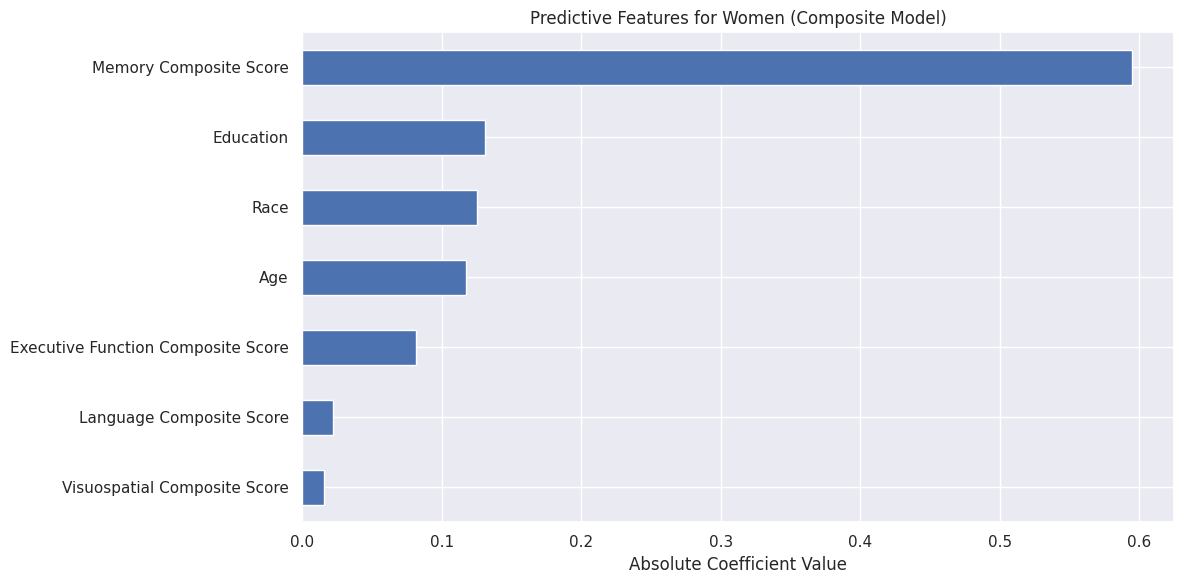

In [90]:
import matplotlib.pyplot as plt

# Get feature importance and take absolute value
fi = run_women2["feature_importance"].abs()

# Rename feature labels
rename_dict = {
    "PHC_MEM": "Memory Composite Score",
    "PHC_VSP": "Visuospatial Composite Score",
    "PHC_EXF": "Executive Function Composite Score",
    "Age_Cognition": "Age",
    "PHC_LAN": "Language Composite Score",
}

fi = fi.rename(index=rename_dict)

# Sort from lowest to highest so the largest bar is at the top
fi_sorted = fi.sort_values(ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(12, 6))
fi_sorted.plot(kind="barh")
plt.title("Predictive Features for Women (Composite Model)")
plt.xlabel("Absolute Coefficient Value")
#plt.ylabel("")  # optional: cleaner
plt.tight_layout()
plt.show()


In [91]:
misclassified_df_women2 = run_women2["X_test_df"]
misclassified_df_women2


misclassified_df_women2.to_csv("/home/xlajoie/Desktop/PhD/misclassified_subjects_women2_MCI_AD.csv", index = False)

misclassified_df_women2

,Education,Race,Age_Cognition,PHC_MEM,PHC_EXF,PHC_LAN,PHC_VSP,True_Label,Predicted_Label,Misclassified
0,12,0,87.934292,0.639,0.305,0.172,0.963,0,0,False
1,14,0,68.339494,0.404,0.410,-0.096,0.963,0,0,False
2,14,0,69.040383,0.471,-0.017,0.643,0.963,1,0,True
3,12,0,83.745380,-0.490,0.200,-0.502,-0.074,0,1,True
4,14,0,83.474333,-0.427,-0.350,-0.213,-0.041,1,1,False
...,...,...,...,...,...,...,...,...,...,...
57,17,0,68.596851,2.183,1.707,1.910,0.963,0,0,False
58,16,0,84.698152,-0.540,0.061,-0.256,0.963,1,1,False
59,18,1,65.768652,1.315,0.802,0.901,0.963,0,0,False
60,12,0,65.886379,0.116,0.778,0.975,0.264,0,0,False


In [93]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.utils import shuffle

# Assume you already have your real accuracy
results = run_women
real_accuracy = results["acc_test"]
print(f"Observed accuracy: {real_accuracy:.4f}")

# Permutation test
n_permutations = 1000
perm_accuracies = []

for _ in range(n_permutations):
    y_permuted = shuffle(y, random_state=None)
    
    # Split with same method as in your function
    X_train, X_test, y_train, y_test = train_test_split(
        x, y_permuted, test_size=0.2, stratify=y_permuted, shuffle=True, random_state=123
    )
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LinearSVC(max_iter=10000))
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    perm_accuracies.append(acc)

# Compute permutation p-value
perm_accuracies = np.array(perm_accuracies)
p_value = np.mean(perm_accuracies >= real_accuracy)

print(f"Permutation p-value: {p_value:.4f}")

NameError: name 'run_women' is not defined

In [94]:
comp_results_all = machine_learning(x2,y2)
comp_results_men = machine_learning(x_men2,y_men2)
comp_results_women = machine_learning(x_women2,y_women2)

PHC_MEM         -0.479974
Education        0.112395
Race            -0.089585
PHC_VSP          0.083306
PHC_EXF         -0.075236
Age_Cognition   -0.067795
Sex              0.038611
PHC_LAN          0.002889
dtype: float64
PHC_MEM         -0.297561
PHC_EXF         -0.109148
Education        0.083879
PHC_VSP          0.080234
Race            -0.062225
Age_Cognition   -0.031850
PHC_LAN         -0.005394
dtype: float64
PHC_MEM         -0.595119
Education        0.130747
Race            -0.125412
Age_Cognition   -0.117373
PHC_EXF         -0.081508
PHC_LAN         -0.022425
PHC_VSP         -0.015517
dtype: float64


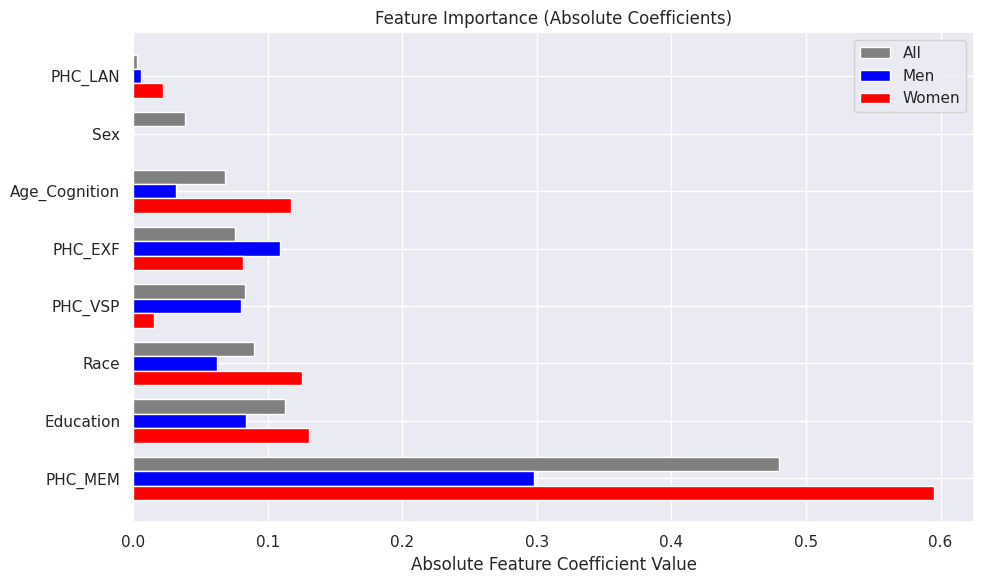

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Combine feature importances into a DataFrame
df_composite = pd.DataFrame({
    'All': comp_results_all['feature_importance'],
    'Men': comp_results_men['feature_importance'],
    'Women': comp_results_women['feature_importance'],
}).fillna(0)

# Take absolute values
df_composite = df_composite.abs()

# Select all features (since we only have 4)
all_features = df_composite['All'].sort_values(ascending=False).index
df_fi_all = df_composite.loc[all_features]

# Sort for prettier horizontal bar plot
df_fi_all = df_fi_all.sort_values(by='All')

# Plotting
plt.figure(figsize=(10, 6))

bar_width = 0.25
indices = np.arange(len(df_fi_all))

plt.barh(indices - bar_width, df_fi_all['All'], height=bar_width, label='All', color='gray')
plt.barh(indices, df_fi_all['Men'], height=bar_width, label='Men', color='blue')
plt.barh(indices + bar_width, df_fi_all['Women'], height=bar_width, label='Women', color='red')

plt.yticks(indices, df_fi_all.index)
plt.xlabel('Absolute Feature Coefficient Value')
plt.title('Feature Importance (Absolute Coefficients)')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

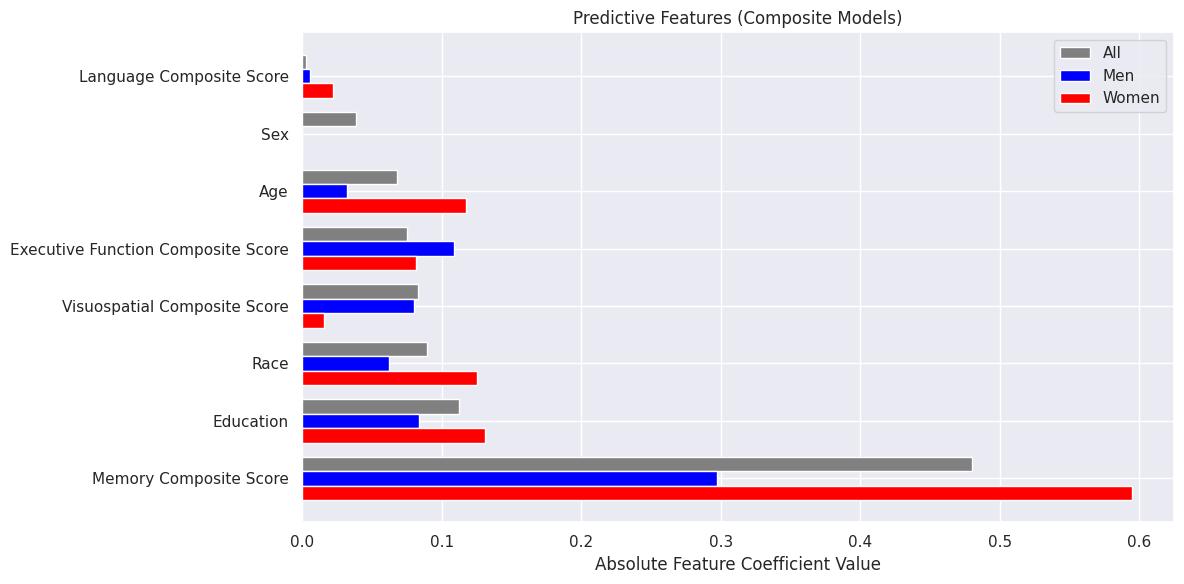

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Combine feature importances into a DataFrame
df_composite = pd.DataFrame({
    'All': comp_results_all['feature_importance'],
    'Men': comp_results_men['feature_importance'],
    'Women': comp_results_women['feature_importance'],
}).fillna(0)

# Take absolute values
df_composite = df_composite.abs()

# Rename feature labels (index)
rename_dict = {
    "PHC_MEM": "Memory Composite Score",
    "PHC_VSP": "Visuospatial Composite Score",
    "PHC_EXF": "Executive Function Composite Score",
    "Age_Cognition": "Age",
    "PHC_LAN": "Language Composite Score",
}

df_composite = df_composite.rename(index=rename_dict)

# Select all features (since we only have a few)
all_features = df_composite['All'].sort_values(ascending=False).index
df_fi_all = df_composite.loc[all_features]

# Sort for prettier horizontal bar plot
df_fi_all = df_fi_all.sort_values(by='All')

# Plotting
plt.figure(figsize=(12, 6))

bar_width = 0.25
indices = np.arange(len(df_fi_all))

plt.barh(indices - bar_width, df_fi_all['All'], height=bar_width, label='All', color='gray')
plt.barh(indices, df_fi_all['Men'], height=bar_width, label='Men', color='blue')
plt.barh(indices + bar_width, df_fi_all['Women'], height=bar_width, label='Women', color='red')

plt.yticks(indices, df_fi_all.index)
plt.xlabel('Absolute Feature Coefficient Value')
plt.title('Predictive Features (Composite Models)')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


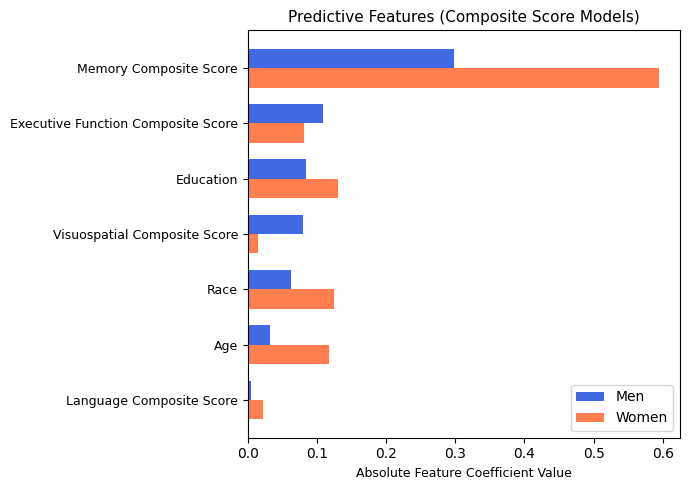

In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Combine feature importances into a DataFrame (Men vs Women only)
df_composite = pd.DataFrame({
    'Men': comp_results_men['feature_importance'],
    'Women': comp_results_women['feature_importance'],
}).fillna(0)

# Take absolute values
df_composite = df_composite.abs()

# Rename feature labels (index)
rename_dict = {
    "PHC_MEM": "Memory Composite Score",
    "PHC_VSP": "Visuospatial Composite Score",
    "PHC_EXF": "Executive Function Composite Score",
    "Age_Cognition": "Age",
    "PHC_LAN": "Language Composite Score",
}

df_composite = df_composite.rename(index=rename_dict)

# Sort features based on Men feature importance for prettier plotting
sorted_features = df_composite['Men'].sort_values(ascending=False).index
df_composite = df_composite.loc[sorted_features]

# Plotting
plt.style.use("default")
plt.figure(figsize=(7, 5))
bar_width = 0.35
indices = np.arange(len(df_composite))

plt.barh(indices - bar_width/2, df_composite['Men'], height=bar_width, label='Men', color='royalblue')
plt.barh(indices + bar_width/2, df_composite['Women'], height=bar_width, label='Women', color='coral')

plt.yticks(indices, df_composite.index, fontsize=9)
plt.xlabel('Absolute Feature Coefficient Value', fontsize=9)
plt.title('Predictive Features (Composite Score Models)', fontsize=11)
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()


plt.savefig("/home/xlajoie/Desktop/PhD/ADNI/composite_men_women.png", dpi=300, bbox_inches="tight")
plt.savefig("/home/xlajoie/Desktop/PhD/ADNI/composite_men_women.pdf", bbox_inches="tight",facecolor="white")

plt.show()



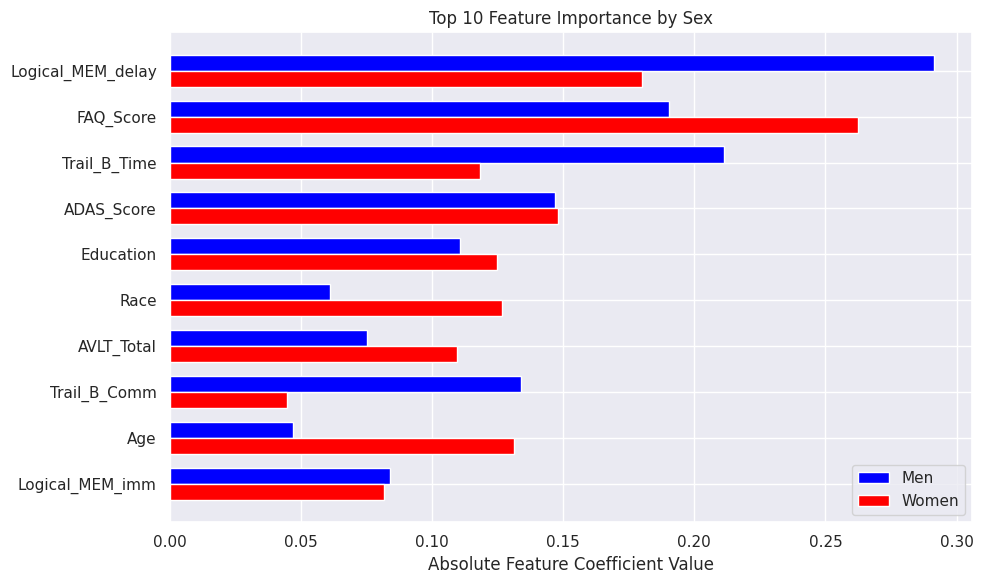

In [98]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Take absolute values of feature importances
fi_men = run_men1["feature_importance"].abs()
fi_women = run_women1["feature_importance"].abs()

# Combine into a DataFrame
df_fi = pd.DataFrame({
    "Men": fi_men,
    "Women": fi_women
}).fillna(0)

# Select top 10 features based on average importance
df_fi["Average"] = df_fi.mean(axis=1)
top10_features = df_fi["Average"].sort_values(ascending=False).head(10).index
df_top10 = df_fi.loc[top10_features]


# Rename feature labels
rename_dict = {
    "PHC_MEM": "Memory Composite Score",
    "PHC_VSP": "Visuospatial Composite Score",
    "PHC_EXF": "Executive Function Composite Score",
    "Age_Cognition": "Age",
    "PHC_LAN": "Language Composite Score",
}

df_top10 = df_top10.rename(index=rename_dict)

# Plot side-by-side horizontal bar chart
plt.figure(figsize=(10,6))
bar_width = 0.35
indices = np.arange(len(df_top10))

plt.barh(indices - bar_width/2, df_top10["Men"], height=bar_width, label="Men", color="blue")
plt.barh(indices + bar_width/2, df_top10["Women"], height=bar_width, label="Women", color="red")

plt.yticks(indices, df_top10.index)
plt.xlabel("Absolute Feature Coefficient Value")
plt.title("Top 10 Feature Importance by Sex")
plt.legend()
plt.gca().invert_yaxis()  # Largest bar on top
plt.tight_layout()
plt.show()


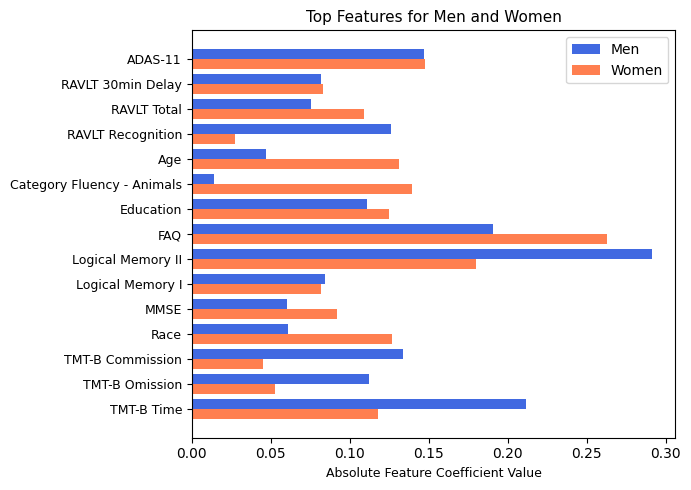

In [122]:
# top 10 for each group 



import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Absolute feature importance
fi_men = run_men1["feature_importance"].abs()
fi_women = run_women1["feature_importance"].abs()

# Get top 10 for each group
top10_men = fi_men.sort_values(ascending=False).head(10)
top10_women = fi_women.sort_values(ascending=False).head(10)

# Take the union of features
top_features = top10_men.index.union(top10_women.index)

# Subset the full DataFrame
df_top = pd.DataFrame({
    "Men": fi_men[top_features],
    "Women": fi_women[top_features]
}).fillna(0)

# Rename feature labels
rename_dict = {
    "ADAS_Score": "ADAS-11",
    "AVDEL30MIN" : "RAVLT 30min Delay",
    "AVLT_Total" : "RAVLT Total",
    "AVRECOGTOT" : "RAVLT Recognition",
    "Age_Cognition" : "Age",
    "Animals_Total" : "Category Fluency - Animals",
    "FAQ_Score" : "FAQ",
    "Logical_MEM_delay" : "Logical Memory II",
    "Logical_MEM_imm" : "Logical Memory I",
    "MMSE_Score" : "MMSE",
    "Trail_B_Comm": "TMT-B Commission",
    "Trail_B_Omm" : "TMT-B Omission",
    "Trail_B_Time": "TMT-B Time",  
    
}

df_top = df_top.rename(index=rename_dict)

# Plot
plt.style.use("default")

plt.figure(figsize=(7, 5))
bar_width = 0.4
indices = np.arange(len(df_top))

plt.barh(indices - bar_width/2, df_top["Men"], height=bar_width, label="Men", color="royalblue")
plt.barh(indices + bar_width/2, df_top["Women"], height=bar_width, label="Women", color="coral")

plt.yticks(indices, df_top.index, fontsize=9)
plt.xlabel("Absolute Feature Coefficient Value", fontsize=9)
plt.title("Top Features for Men and Women", fontsize=11)
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()


plt.savefig("/home/xlajoie/Desktop/PhD/ADNI/top_features_men_women.png", dpi=300, bbox_inches="tight")

plt.savefig("/home/xlajoie/Desktop/PhD/ADNI/top_features_men_women.pdf",bbox_inches="tight")

plt.show()


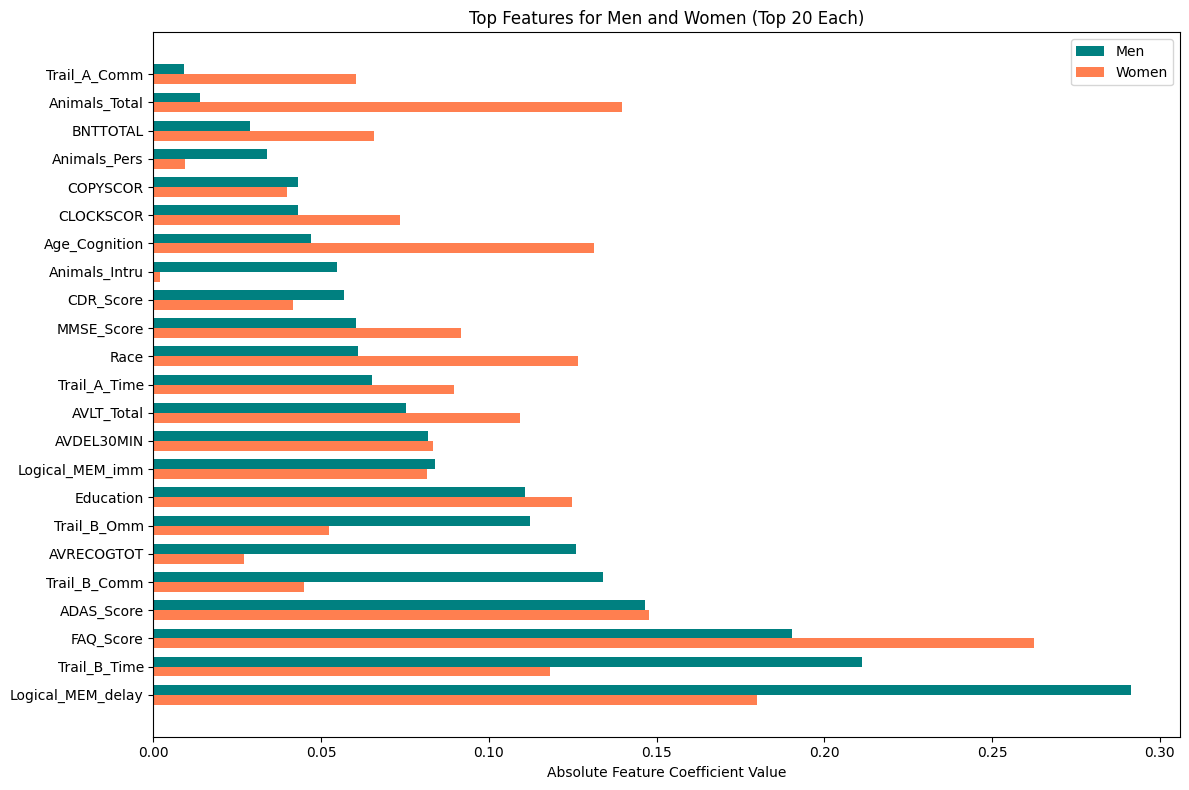

In [116]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Absolute feature importance
fi_men = run_men1["feature_importance"].abs()
fi_women = run_women1["feature_importance"].abs()

# Get top 20 features for each group
top20_men = fi_men.sort_values(ascending=False).head(20)
top20_women = fi_women.sort_values(ascending=False).head(20)

# Union of top features
top_features = top20_men.index.union(top20_women.index)

# Subset the full DataFrame
df_top = pd.DataFrame({
    "Men": fi_men[top_features],
    "Women": fi_women[top_features]
}).fillna(0)

# Optional: sort by Men importance (or by max of Men/Women)
df_top = df_top.sort_values(by="Men", ascending=True)  # largest bar on top

# Plot
plt.figure(figsize=(12, 8))
bar_width = 0.35
indices = np.arange(len(df_top))

plt.barh(indices - bar_width/2, df_top["Men"], height=bar_width, label="Men", color="teal")
plt.barh(indices + bar_width/2, df_top["Women"], height=bar_width, label="Women", color="coral")

plt.yticks(indices, df_top.index)
plt.xlabel("Absolute Feature Coefficient Value")
plt.title("Top Features for Men and Women (Top 20 Each)")
plt.legend()
#plt.grid(False)
plt.gca().invert_yaxis()  # largest bar on top
plt.tight_layout()
plt.show()


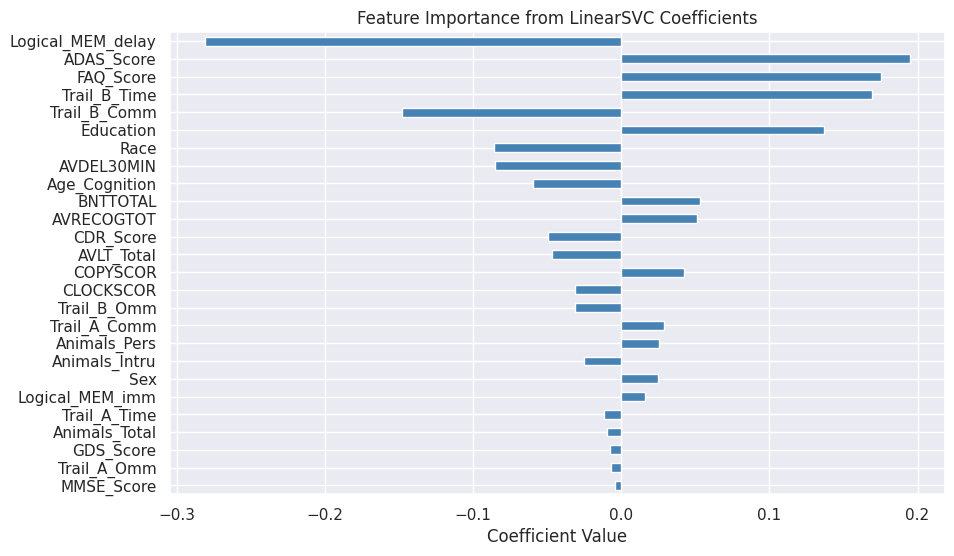

In [101]:
import matplotlib.pyplot as plt

# Assuming `results` is the dictionary returned by your function:
# results = machine_learning(x, y)

feature_importance = results["feature_importance"]

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh', color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance from LinearSVC Coefficients')
plt.gca().invert_yaxis()  # Show highest absolute coefficient at the top
plt.show()


In [102]:
feature_name_mapping = {
    'Logical_MEM_delay': 'Logical Memory (Delayed Recall)',
    'PHC_MEM': 'PHC Memory Composite',
    'Trail_B_Time': 'Trail Making Test B - Time',
    'FAQ_Score': 'Functional Activities Questionnaire (FAQ)',
    'ADAS_Score': 'Alzheimer’s Disease Assessment Scale (ADAS-Cog)',
    'Trail_B_Comm': 'Trail Making Test B - Commission Errors',
    'Education': 'Education',
    'Race': 'Race',
    'AVRECOGTOT': 'RAVLT Recognition Total',
    'PHC_VSP': 'PHC Visuospatial Composite',
    'CLOCKSCOR': 'Clock Drawing Test - Score',
    'Age_Cognition': 'Age',
    'PHC_EXF': 'PHC Executive Function Composite',
    'BNTTOTAL': 'Boston Naming Test - Total Score',
    'CDR_Score': 'Clinical Dementia Rating (CDR) Global Score',
    'AVDEL30MIN': 'RAVLT Delayed Recall (30 min)',
    'Trail_B_Omm': 'Trail Making Test B - Omission Errors',
    'Animals_Intru': 'Animal Fluency - Intrusions',
    'Trail_A_Comm': 'Trail Making Test A - Commission Errors',
    'Animals_Pers': 'Animal Fluency - Perseverations',
    'Sex': 'Biological Sex',
    'Logical_MEM_imm': 'Logical Memory (Immediate Recall)',
    'AVLT_Total': 'RAVLT Total Learning Score',
    'Trail_A_Omm': 'Trail Making Test A - Omission Errors',
    'MMSE_Score': 'Mini-Mental State Examination (MMSE)',
    'PHC_LAN': 'PHC Language Composite',
    'GDS_Score': 'Geriatric Depression Scale (GDS)',
    'COPYSCOR': 'Clock Drawing Test - Copy Score',
    'Trail_A_Time': 'Trail Making Test A - Time',
    'Animals_Total': 'Animal Fluency - Total Score'
}


In [103]:
feature_name_mapping_men = {
    'Logical_MEM_delay': 'Logical Memory (Delayed Recall)',
    'Trail_B_Time': 'Trail Making Test B - Time',
    'FAQ_Score': 'Functional Activities Questionnaire (FAQ)',
    'AVRECOGTOT': 'RAVLT Recognition Total',
    'Trail_B_Comm': 'Trail Making Test B - Commission Errors',
    'ADAS_Score': 'Alzheimer’s Disease Assessment Scale (ADAS-Cog)',
    'Trail_B_Omm': 'Trail Making Test B - Omission Errors',
    'Education': 'Education',
    'Logical_MEM_imm': 'Logical Memory (Immediate Recall)',
    'Trail_A_Time': 'Trail Making Test A - Time',
    'PHC_MEM': 'PHC Memory Composite',
    'AVDEL30MIN': 'RAVLT Delayed Recall (30 min)',
    'Race': 'Race',
    'MMSE_Score': 'Mini-Mental State Examination (MMSE)',
    'PHC_VSP': 'PHC Visuospatial Composite',
    'Animals_Intru': 'Animal Fluency - Intrusions',
    'CLOCKSCOR': 'Clock Drawing Test - Score',
    'CDR_Score': 'Clinical Dementia Rating (CDR) Global Score',
    'AVLT_Total': 'RAVLT Total Learning Score',
    'Age_Cognition': 'Age',
    'Animals_Pers': 'Animal Fluency - Perseverations',
    'Trail_A_Omm': 'Trail Making Test A - Omission Errors',
    'BNTTOTAL': 'Boston Naming Test - Total Score',
    'Animals_Total': 'Animal Fluency - Total Score',
    'PHC_LAN': 'PHC Language Composite',
    'PHC_EXF': 'PHC Executive Function Composite',
    'Trail_A_Comm': 'Trail Making Test A - Commission Errors',
    'GDS_Score': 'Geriatric Depression Scale (GDS)',
    'COPYSCOR': 'Clock Drawing Test - Copy Score'
}


In [104]:
feature_name_mapping_women = {
    'PHC_MEM': 'PHC Memory Composite',
    'FAQ_Score': 'Functional Activities Questionnaire (FAQ)',
    'Education': 'Education',
    'Animals_Total': 'Animal Fluency - Total Score',
    'Age_Cognition': 'Age',
    'Trail_A_Time': 'Trail Making Test A - Time',
    'Race': 'Race',
    'Logical_MEM_delay': 'Logical Memory (Delayed Recall)',
    'Trail_B_Time': 'Trail Making Test B - Time',
    'AVDEL30MIN': 'RAVLT Delayed Recall (30 min)',
    'Logical_MEM_imm': 'Logical Memory (Immediate Recall)',
    'AVLT_Total': 'RAVLT Total Learning Score',
    'PHC_EXF': 'PHC Executive Function Composite',
    'Trail_B_Omm': 'Trail Making Test B - Omission Errors',
    'Trail_A_Comm': 'Trail Making Test A - Commission Errors',
    'PHC_VSP': 'PHC Visuospatial Composite',
    'CLOCKSCOR': 'Clock Drawing Test - Score',
    'PHC_LAN': 'PHC Language Composite',
    'AVRECOGTOT': 'RAVLT Recognition Total',
    'CDR_Score': 'Clinical Dementia Rating (CDR) Global Score',
    'Trail_B_Comm': 'Trail Making Test B - Commission Errors',
    'GDS_Score': 'Geriatric Depression Scale (GDS)',
    'Animals_Pers': 'Animal Fluency - Perseverations',
    'ADAS_Score': 'Alzheimer’s Disease Assessment Scale (ADAS-Cog)',
    'BNTTOTAL': 'Boston Naming Test - Total Score',
    'COPYSCOR': 'Clock Drawing Test - Copy Score',
    'Animals_Intru': 'Animal Fluency - Intrusions',
    'Trail_A_Omm': 'Trail Making Test A - Omission Errors'
}


In [105]:
results_all = machine_learning(x,y)
results_men = machine_learning(x_men, y_men)
results_women = machine_learning(x_women, y_women)


import pandas as pd

df_fi = pd.DataFrame({
    'All': results_all['feature_importance'],
    'Men': results_men['feature_importance'],
    'Women': results_women['feature_importance'],
}).fillna(0)  # fill missing features with 0 importance


import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))

# Sort features by importance in 'All' (or by mean importance)
features_sorted = df_fi['All'].abs().sort_values(ascending=False).index

df_fi = df_fi.loc[features_sorted]

bar_width = 0.25
indices = np.arange(len(df_fi))

plt.barh(indices - bar_width, df_fi['All'], height=bar_width, label='All', color='gray')
plt.barh(indices, df_fi['Men'], height=bar_width, label='Men', color='blue')
plt.barh(indices + bar_width, df_fi['Women'], height=bar_width, label='Women', color='red')

plt.yticks(indices, df_fi.index)
plt.xlabel('Feature Coefficient Value')
plt.title('Feature Importance Comparison Across Models')
plt.legend()
plt.gca().invert_yaxis()  # highest importance on top
plt.tight_layout()
plt.show()


Logical_MEM_delay   -0.281078
ADAS_Score           0.194713
FAQ_Score            0.175657
Trail_B_Time         0.169561
Trail_B_Comm        -0.147853
Education            0.136871
Race                -0.086149
AVDEL30MIN          -0.085663
Age_Cognition       -0.059420
BNTTOTAL             0.053244
AVRECOGTOT           0.050910
CDR_Score           -0.049672
AVLT_Total          -0.046759
COPYSCOR             0.042396
CLOCKSCOR           -0.031550
Trail_B_Omm         -0.031190
Trail_A_Comm         0.029047
Animals_Pers         0.025654
Animals_Intru       -0.025485
Sex                  0.024536
Logical_MEM_imm      0.015943
Trail_A_Time        -0.012049
Animals_Total       -0.009776
GDS_Score           -0.007475
Trail_A_Omm         -0.007246
MMSE_Score          -0.004599
dtype: float64


NameError: name 'x_men' is not defined

In [ ]:
import matplotlib.pyplot as plt

results_all = machine_learning(x,y)
results_men = machine_learning(x_men, y_men)
results_women = machine_learning(x_women, y_women)



def plot_feature_importance(feature_importance, title):
    plt.figure(figsize=(10, 6))
    feature_importance.plot(kind='barh', color='teal')
    plt.xlabel('Coefficient Value')
    plt.title(title)
    plt.gca().invert_yaxis()  # highest importance on top
    plt.show()

plot_feature_importance(results_all['feature_importance'], 'Feature Importance - All Subjects')
plot_feature_importance(results_men['feature_importance'], 'Feature Importance - Men')
plot_feature_importance(results_women['feature_importance'], 'Feature Importance - Women')


In [ ]:
import matplotlib.pyplot as plt

def plot_feature_importance_abs(feature_importance, title):
    plt.figure(figsize=(10, 10))
    feature_importance_abs = feature_importance.abs()
    feature_importance_abs = feature_importance_abs.sort_values(ascending=True)
    feature_importance_abs.plot(kind='barh', color='purple')
    plt.xlabel('Absolute Coefficient Value')
    plt.title(title + ' (Absolute Values)')
    plt.show()

# Assuming you have results for each:
plot_feature_importance_abs(results_all['feature_importance'], 'Feature Importance - All Subjects')
plot_feature_importance_abs(results_men['feature_importance'], 'Feature Importance - Men')
plot_feature_importance_abs(results_women['feature_importance'], 'Feature Importance - Women')


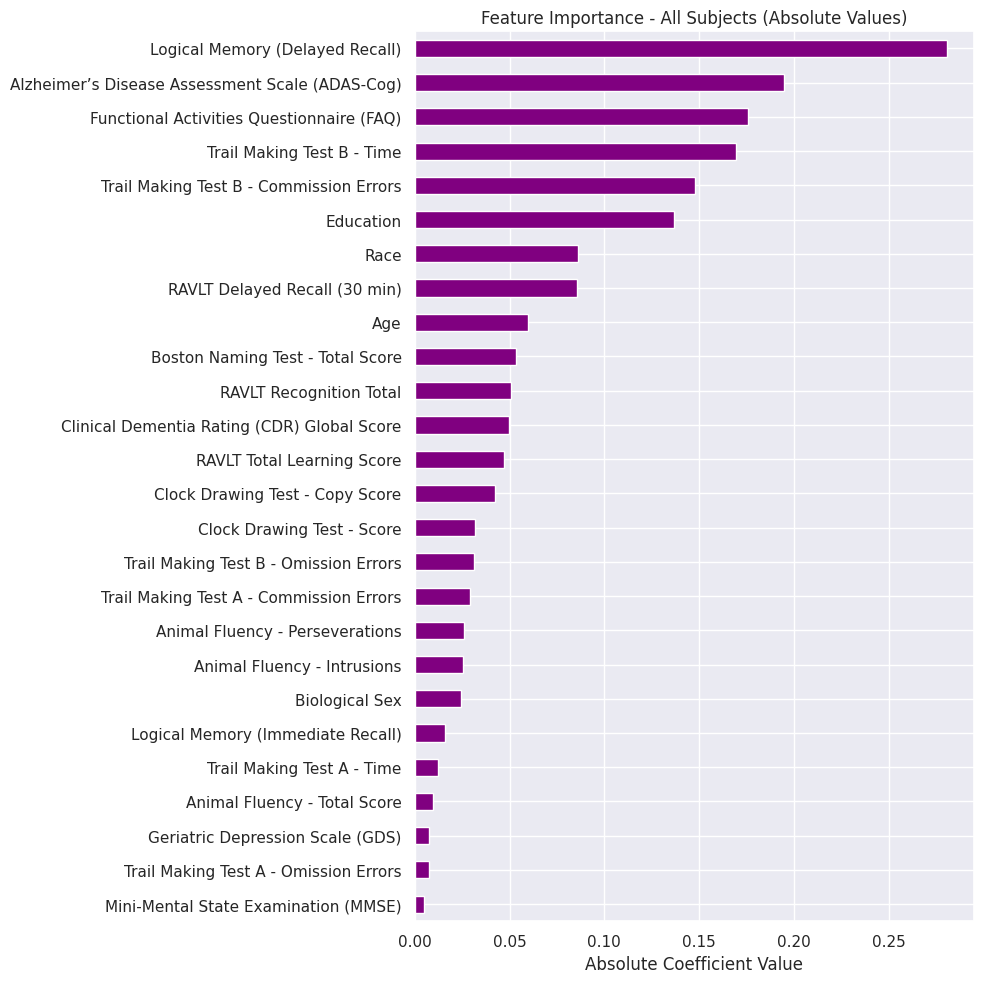

NameError: name 'results_men' is not defined

In [106]:
import matplotlib.pyplot as plt

def plot_feature_importance_abs(feature_importance, title, feature_name_mapping):
    plt.figure(figsize=(10, 10))
    feature_importance_abs = feature_importance.abs()
    # Rename features using the mapping (keep original if not found)
    feature_importance_abs = feature_importance_abs.rename(index=lambda x: feature_name_mapping.get(x, x))
    feature_importance_abs = feature_importance_abs.sort_values(ascending=True)
    feature_importance_abs.plot(kind='barh', color='purple')
    plt.xlabel('Absolute Coefficient Value')
    plt.title(title + ' (Absolute Values)')
    plt.tight_layout()
    plt.show()

# Call the function with each results and corresponding mapping

plot_feature_importance_abs(results_all['feature_importance'], 'Feature Importance - All Subjects', feature_name_mapping)
plot_feature_importance_abs(results_men['feature_importance'], 'Feature Importance - Men', feature_name_mapping_men)
plot_feature_importance_abs(results_women['feature_importance'], 'Feature Importance - Women', feature_name_mapping_women)


In [ ]:
import matplotlib.pyplot as plt

def plot_top10_feature_importance_abs(feature_importance, title, feature_name_mapping):
    plt.figure(figsize=(15, 5))
    feature_importance_abs = feature_importance.abs()
    top10_features = feature_importance_abs.sort_values(ascending=False).head(10)
    # Rename top 10 features using the mapping (keep original if not found)
    top10_features = top10_features.rename(index=lambda x: feature_name_mapping.get(x, x))
    top10_features = top10_features.sort_values()  # sort for prettier horizontal bar plot
    top10_features.plot(kind='barh', color='purple')
    plt.xlabel('Absolute Coefficient Value')
    plt.title(title + ' - Top 10 Features (Absolute Values)')
    plt.tight_layout()
    plt.show()

# Call the function with each results and corresponding mapping

plot_top10_feature_importance_abs(results_all['feature_importance'], 'Feature Importance - All Subjects', feature_name_mapping)
plot_top10_feature_importance_abs(results_men['feature_importance'], 'Feature Importance - Men', feature_name_mapping_men)
plot_top10_feature_importance_abs(results_women['feature_importance'], 'Feature Importance - Women', feature_name_mapping_women)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Combine feature importances into a DataFrame
df_fi = pd.DataFrame({
    'All': results_all['feature_importance'],
    'Men': results_men['feature_importance'],
    'Women': results_women['feature_importance'],
}).fillna(0)

# Take absolute values
df_fi = df_fi.abs()

# Select top 10 features based on 'All'
top10_features = df_fi['All'].sort_values(ascending=False).head(10).index
df_fi_top10 = df_fi.loc[top10_features]

# Sort for prettier horizontal bar plot
df_fi_top10 = df_fi_top10.sort_values(by='All')

# Plotting
plt.figure(figsize=(12, 8))

bar_width = 0.25
indices = np.arange(len(df_fi_top10))

plt.barh(indices - bar_width, df_fi_top10['All'], height=bar_width, label='All', color='gray')
plt.barh(indices, df_fi_top10['Men'], height=bar_width, label='Men', color='blue')
plt.barh(indices + bar_width, df_fi_top10['Women'], height=bar_width, label='Women', color='red')

plt.yticks(indices, df_fi_top10.index)
plt.xlabel('Absolute Feature Coefficient Value')
plt.title('Top 10 Most Important Features (Absolute Coefficients)')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Combine feature importances into a DataFrame
df_fi = pd.DataFrame({
    'All': results_all['feature_importance'],
    'Men': results_men['feature_importance'],
    'Women': results_women['feature_importance'],
}).fillna(0)

# Take absolute values
df_fi = df_fi.abs()

# Sort features by 'All' importance
df_fi = df_fi.sort_values(by='All')

# Plotting
plt.figure(figsize=(12, max(6, 0.4 * len(df_fi))))  # adjust height for many features

bar_width = 0.25
indices = np.arange(len(df_fi))

plt.barh(indices - bar_width, df_fi['All'], height=bar_width, label='All', color='gray')
plt.barh(indices, df_fi['Men'], height=bar_width, label='Men', color='blue')
plt.barh(indices + bar_width, df_fi['Women'], height=bar_width, label='Women', color='red')

plt.yticks(indices, df_fi.index)
plt.xlabel('Absolute Feature Coefficient Value')
plt.title('Feature Importance Comparison (Absolute Values)')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
